# Kenya Hockey Union — League & Team Analytics

This notebook takes the raw scraped data from `01_scraping.ipynb` and
builds the foundational analytics layer: league tables, results
datasets, and first-pass team/player statistics (scoring, discipline,
home vs away, attack vs defence, form).

**Input:** `data/raw/matches_2026.csv`, `data/raw/events_2026.csv`
**Output:** processed datasets in `data/processed/`, consumed by
`03_advanced_analytics.ipynb`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# Load raw scraped datasets
# --------------------------

matches_df = pd.read_csv("../data/raw/matches_2026.csv")
events_df = pd.read_csv("../data/raw/events_2026.csv")

print(f"Matches loaded : {len(matches_df)}")
print(f"Events loaded  : {len(events_df)}")


Matches loaded : 177
Events loaded  : 209


## Results & League Table Construction

Derive match results, points, and build the season league table.

In [2]:
# Cell 39 - Event Summary

events_df["Event"].value_counts()

Event
Goal           104
Green Card      62
Yellow card     42
Red Card         1
Name: count, dtype: int64

In [3]:
# Cell 40 - Goal Scorers

goal_scorers = (
    events_df[events_df["Event"] == "Goal"]
    .groupby(["Player", "Team"])
    .size()
    .reset_index(name="Goals")
    .sort_values("Goals", ascending=False)
)

goal_scorers.head(20)

,Player,Team,Goals
48,Mathias Gularire,Sikh Union Nairobi,6
56,Robert Masibo,Kenya Police,4
45,Malack Masese,Kisumu Youngsters,4
33,Job Wandera,Wazalendo,4
8,Calvins Kanu Omondi,Warriors,3
12,Cliff Omari,Sikh Union Nairobi,3
58,Sheldone Kimtai,Western Jaguars,3
20,Eudgas Lirhu,Parklands Sports Club,3
47,Mathew Momanyi,Wazalendo,2
19,Esbon Ombui,Daikyo Heroes,2


In [4]:
# Cell 41 - Team Results

team_stats = []

for _, row in matches_df.iterrows():

    # Home
    team_stats.append({
        "Team": row["HomeTeam"],
        "GF": row["HomeGoals"],
        "GA": row["AwayGoals"]
    })

    # Away
    team_stats.append({
        "Team": row["AwayTeam"],
        "GF": row["AwayGoals"],
        "GA": row["HomeGoals"]
    })

team_stats = pd.DataFrame(team_stats)

team_stats.head()

,Team,GF,GA
0,Amira Sailors Hockey Club,0,3
1,Blazers Hockey Club,3,0
2,Amira Sailors Hockey Club,0,0
3,Sliders Hockey Club,0,0
4,Blazers Hockey Club,2,0


In [5]:
# Cell 42 - Home Results

home_results = matches_df.copy()

home_results["Team"] = home_results["HomeTeam"]
home_results["Opponent"] = home_results["AwayTeam"]

home_results["GF"] = home_results["HomeGoals"]
home_results["GA"] = home_results["AwayGoals"]

home_results["Venue"] = "Home"

home_results = home_results[
    [
        "Competition",
        "Team",
        "Opponent",
        "Venue",
        "GF",
        "GA"
    ]
]

home_results.head()


,Competition,Team,Opponent,Venue,GF,GA
0,PLW,Amira Sailors Hockey Club,Blazers Hockey Club,Home,0,3
1,PLW,Amira Sailors Hockey Club,Sliders Hockey Club,Home,0,0
2,PLW,Blazers Hockey Club,Kenyatta University Ladies,Home,2,0
3,PLW,Blazers Hockey Club,Kisumu Queens,Home,1,0
4,PLW,Blazers Hockey Club,Sliders Hockey Club,Home,3,0


In [6]:
# Cell 43 - Away Results

away_results = matches_df.copy()

away_results["Team"] = away_results["AwayTeam"]
away_results["Opponent"] = away_results["HomeTeam"]

away_results["GF"] = away_results["AwayGoals"]
away_results["GA"] = away_results["HomeGoals"]

away_results["Venue"] = "Away"

away_results = away_results[
    [
        "Competition",
        "Team",
        "Opponent",
        "Venue",
        "GF",
        "GA"
    ]
]

away_results.head()


,Competition,Team,Opponent,Venue,GF,GA
0,PLW,Blazers Hockey Club,Amira Sailors Hockey Club,Away,3,0
1,PLW,Sliders Hockey Club,Amira Sailors Hockey Club,Away,0,0
2,PLW,Kenyatta University Ladies,Blazers Hockey Club,Away,0,2
3,PLW,Kisumu Queens,Blazers Hockey Club,Away,0,1
4,PLW,Sliders Hockey Club,Blazers Hockey Club,Away,0,3


In [7]:
# Cell 44 - Combine Results

results = pd.concat(
    [home_results, away_results],
    ignore_index=True
)

results.head()

,Competition,Team,Opponent,Venue,GF,GA
0,PLW,Amira Sailors Hockey Club,Blazers Hockey Club,Home,0,3
1,PLW,Amira Sailors Hockey Club,Sliders Hockey Club,Home,0,0
2,PLW,Blazers Hockey Club,Kenyatta University Ladies,Home,2,0
3,PLW,Blazers Hockey Club,Kisumu Queens,Home,1,0
4,PLW,Blazers Hockey Club,Sliders Hockey Club,Home,3,0


In [8]:
# Cell 45 - Wins Draws Losses

results["Win"] = (results["GF"] > results["GA"]).astype(int)

results["Draw"] = (results["GF"] == results["GA"]).astype(int)

results["Loss"] = (results["GF"] < results["GA"]).astype(int)

results.head()

,Competition,Team,Opponent,Venue,GF,GA,Win,Draw,Loss
0,PLW,Amira Sailors Hockey Club,Blazers Hockey Club,Home,0,3,0,0,1
1,PLW,Amira Sailors Hockey Club,Sliders Hockey Club,Home,0,0,0,1,0
2,PLW,Blazers Hockey Club,Kenyatta University Ladies,Home,2,0,1,0,0
3,PLW,Blazers Hockey Club,Kisumu Queens,Home,1,0,1,0,0
4,PLW,Blazers Hockey Club,Sliders Hockey Club,Home,3,0,1,0,0


In [9]:
# Cell 46 - Points

results["Points"] = (
    results["Win"] * 3 +
    results["Draw"]
)

results.head()

,Competition,Team,Opponent,Venue,GF,GA,Win,Draw,Loss,Points
0,PLW,Amira Sailors Hockey Club,Blazers Hockey Club,Home,0,3,0,0,1,0
1,PLW,Amira Sailors Hockey Club,Sliders Hockey Club,Home,0,0,0,1,0,1
2,PLW,Blazers Hockey Club,Kenyatta University Ladies,Home,2,0,1,0,0,3
3,PLW,Blazers Hockey Club,Kisumu Queens,Home,1,0,1,0,0,3
4,PLW,Blazers Hockey Club,Sliders Hockey Club,Home,3,0,1,0,0,3


In [10]:
# Cell 47 - League Table

# Grouped by Competition + Team so each of the 8 competitions gets its
# own standings, rather than pooling every team from every competition
# into one flat table.

league_table = (
    results
    .groupby(["Competition", "Team"])
    .agg(
        Played=("Team", "count"),
        Wins=("Win", "sum"),
        Draws=("Draw", "sum"),
        Losses=("Loss", "sum"),
        GF=("GF", "sum"),
        GA=("GA", "sum"),
        Points=("Points", "sum")
    )
    .reset_index()
)

league_table["GD"] = league_table["GF"] - league_table["GA"]

league_table = league_table[
    [
        "Competition",
        "Team",
        "Played",
        "Wins",
        "Draws",
        "Losses",
        "GF",
        "GA",
        "GD",
        "Points"
    ]
]

league_table = league_table.sort_values(
    ["Competition", "Points", "GD", "GF"],
    ascending=[True, False, False, False]
)

league_table


,Competition,Team,Played,Wins,Draws,Losses,GF,GA,GD,Points
1,NLM-CZ,GHF Rift Pirates Men,1,1,0,0,9,1,8,3
3,NLM-CZ,Thika Rovers,1,1,0,0,8,0,8,3
0,NLM-CZ,Dukes of Gloucester,3,1,0,2,6,17,-11,3
2,NLM-CZ,Nyari Hockey Club,1,0,0,1,0,5,-5,0
12,NLM-EZ,Ulinzi Patriots,8,5,2,1,14,8,6,17
...,...,...,...,...,...,...,...,...,...,...
60,SLW,Swans Hockey Club,4,1,2,1,4,4,0,5
55,SLW,Daystar University Ladies,5,1,0,4,3,9,-6,3
59,SLW,Mombasa Sports Club Ladies,4,0,2,2,3,5,-2,2
57,SLW,Gorillas Hockey Club – Ladies,3,0,0,3,2,6,-4,0


In [11]:
# Cell 48 - League Position

# Position now resets to 1 at the top of each competition, instead of
# numbering straight through all 8 competitions as if they were one table.

league_table["Position"] = (
    league_table
    .groupby("Competition")
    .cumcount() + 1
)

cols = ["Position"] + [c for c in league_table.columns if c != "Position"]
league_table = league_table[cols]

league_table


,Position,Competition,Team,Played,Wins,Draws,Losses,GF,GA,GD,Points
1,1,NLM-CZ,GHF Rift Pirates Men,1,1,0,0,9,1,8,3
3,2,NLM-CZ,Thika Rovers,1,1,0,0,8,0,8,3
0,3,NLM-CZ,Dukes of Gloucester,3,1,0,2,6,17,-11,3
2,4,NLM-CZ,Nyari Hockey Club,1,0,0,1,0,5,-5,0
12,1,NLM-EZ,Ulinzi Patriots,8,5,2,1,14,8,6,17
...,...,...,...,...,...,...,...,...,...,...,...
60,5,SLW,Swans Hockey Club,4,1,2,1,4,4,0,5
55,6,SLW,Daystar University Ladies,5,1,0,4,3,9,-6,3
59,7,SLW,Mombasa Sports Club Ladies,4,0,2,2,3,5,-2,2
57,8,SLW,Gorillas Hockey Club – Ladies,3,0,0,3,2,6,-4,0


In [12]:
# Cell 49 - Save League Table

league_table.to_csv(
    "../data/processed/league_table.csv",
    index=False
)

print("League table saved.")

League table saved.


## Scoring & Discipline Analytics

Goal scorers, team goal totals, card summaries, and goal-timing analysis.

In [13]:
# Cell 50 - Team Summary

team_summary = (
    results
    .groupby(["Competition", "Team"])
    .agg(
        Matches=("Team", "count"),
        GoalsFor=("GF", "sum"),
        GoalsAgainst=("GA", "sum"),
        Wins=("Win", "sum"),
        Draws=("Draw", "sum"),
        Losses=("Loss", "sum")
    )
    .reset_index()
)

team_summary["GoalDifference"] = (
    team_summary["GoalsFor"] -
    team_summary["GoalsAgainst"]
)

team_summary


,Competition,Team,Matches,GoalsFor,GoalsAgainst,Wins,Draws,Losses,GoalDifference
0,NLM-CZ,Dukes of Gloucester,3,6,17,1,0,2,-11
1,NLM-CZ,GHF Rift Pirates Men,1,9,1,1,0,0,8
2,NLM-CZ,Nyari Hockey Club,1,0,5,0,0,1,-5
3,NLM-CZ,Thika Rovers,1,8,0,1,0,0,8
4,NLM-EZ,Black Tigers,9,13,12,4,1,4,1
...,...,...,...,...,...,...,...,...,...
58,SLW,Lakers Hockey Club – B,6,7,5,3,2,1,2
59,SLW,Mombasa Sports Club Ladies,4,3,5,0,2,2,-2
60,SLW,Swans Hockey Club,4,4,4,1,2,1,0
61,SLW,Twinkle Hockey Club,5,13,3,4,1,0,10


In [14]:
# Cell 51 - Save Team Summary

team_summary.to_csv(
    "../data/processed/team_summary.csv",
    index=True
)

print("Team summary saved.")

Team summary saved.


In [15]:
# Cell 52 - Goal Events

goals = events_df[
    events_df["Event"] == "Goal"
].copy()

print("Goals:", len(goals))

goals.head()

Goals: 104


,Competition,Season,MatchNo,Date,HomeTeam,AwayTeam,Minute,Event,Player,Team
0,PLW,2026,14.0,24-05-2026,Amira Sailors Hockey Club,Blazers Hockey Club,16',Goal,Audrey Omaido,Blazers Hockey Club
1,PLW,2026,14.0,24-05-2026,Amira Sailors Hockey Club,Blazers Hockey Club,42',Goal,Joan Ajao,Blazers Hockey Club
2,PLW,2026,14.0,24-05-2026,Amira Sailors Hockey Club,Blazers Hockey Club,44',Goal,Amanda Ijai,Blazers Hockey Club
4,PLW,2026,1.0,23-05-2026,Blazers Hockey Club,Kenyatta University Ladies,36',Goal,Joan Ajao,Blazers Hockey Club
5,PLW,2026,1.0,23-05-2026,Blazers Hockey Club,Kenyatta University Ladies,53',Goal,Vivian Onyango,Blazers Hockey Club


In [16]:
# Cell 53 - Top Scorers

top_scorers = (
    goals
    .groupby(
        ["Competition", "Player", "Team"]
    )
    .size()
    .reset_index(name="Goals")
)

top_scorers = top_scorers.sort_values(
    ["Competition", "Goals"],
    ascending=[True, False]
)

top_scorers


,Competition,Player,Team,Goals
38,PLM,Mathias Gularire,Sikh Union Nairobi,6
26,PLM,Job Wandera,Wazalendo,4
36,PLM,Malack Masese,Kisumu Youngsters,4
42,PLM,Robert Masibo,Kenya Police,4
6,PLM,Calvins Kanu Omondi,Warriors,3
...,...,...,...,...
60,PLW,Mitchell Akoth,UON Ladies,1
61,PLW,Nichole Joy,Strathmore University Ladies,1
62,PLW,Noela Kimathi,UON Ladies,1
63,PLW,Vivian Onyango,Blazers Hockey Club,1


In [17]:
# Cell 54 - Save Top Scorers

top_scorers.to_csv(
    "../data/processed/top_scorers.csv",
    index=False
)

print("Top scorers saved.")

Top scorers saved.


In [18]:
# Cell 55 - Card Events

cards = events_df[
    events_df["Event"].str.contains(
        "Card",
        na=False
    )
].copy()

cards.head()

,Competition,Season,MatchNo,Date,HomeTeam,AwayTeam,Minute,Event,Player,Team
3,PLW,2026,1.0,23-05-2026,Blazers Hockey Club,Kenyatta University Ladies,27',Green Card,Joan Ajao,Blazers Hockey Club
9,PLW,2026,10.0,24-05-2026,Kenyatta University Ladies,Sliders Hockey Club,35',Green Card,Chamchui Esther,Sliders Hockey Club
10,PLW,2026,12.0,24-05-2026,Lakers Hockey Club,Kisumu Queens,12',Green Card,Beryl Achieng,Kisumu Queens
11,PLW,2026,12.0,24-05-2026,Lakers Hockey Club,Kisumu Queens,29',Green Card,Faith Amondi,Lakers Hockey Club
12,PLW,2026,12.0,24-05-2026,Lakers Hockey Club,Kisumu Queens,37',Green Card,Vivian Juma,Lakers Hockey Club


In [19]:
# Cell 56 - Card Summary

card_summary = (
    cards
    .groupby(
        ["Competition", "Player", "Team", "Event"]
    )
    .size()
    .reset_index(name="Count")
)

card_summary


,Competition,Player,Team,Event,Count
0,PLM,Allan Iningu,Warriors,Green Card,1
1,PLM,Aredha Mandela,Parklands Sports Club,Green Card,1
2,PLM,Arjun Uupta,Sikh Union Nairobi,Green Card,1
3,PLM,Asher Ochieng,Kisumu Youngsters,Green Card,1
4,PLM,Benon Papa,Greensharks,Green Card,1
5,PLM,Benson Mawich,Greensharks,Green Card,1
6,PLM,Bonny Ndombi,Daikyo Heroes,Green Card,1
7,PLM,Bravel Lumiti,Kisumu Youngsters,Green Card,1
8,PLM,Brian Oyato,Parklands Sports Club,Green Card,1
9,PLM,Calvins Kanu Omondi,Warriors,Green Card,3


In [20]:
# Cell 57 - Save Card Summary

card_summary.to_csv(
    "../data/processed/card_summary.csv",
    index=False
)

print("Card summary saved.")

Card summary saved.


In [21]:
# Cell 58 - Goals by Team

team_goals = (
    goals
    .groupby(["Competition", "Team"])
    .size()
    .reset_index(name="Goals")
    .sort_values(
        ["Competition", "Goals"],
        ascending=[True, False]
    )
)

team_goals


,Competition,Team,Goals
5,PLM,Sikh Union Nairobi,13
9,PLM,Western Jaguars,11
7,PLM,Warriors,10
8,PLM,Wazalendo,10
0,PLM,Daikyo Heroes,9
4,PLM,Parklands Sports Club,9
2,PLM,Kenya Police,7
6,PLM,USIU – A,7
3,PLM,Kisumu Youngsters,6
1,PLM,Greensharks,1


In [22]:
# Cell 59 - Save Team Goals

team_goals.to_csv(
    "../data/processed/team_goals.csv",
    index=False
)

print("Team goals saved.")

Team goals saved.


In [23]:
# Cell 60 - Goal Minutes (Fixed)

goal_minutes = goals.copy()

# Remove apostrophe
goal_minutes["Minute"] = (
    goal_minutes["Minute"]
    .str.replace("'", "", regex=False)
)

# Convert 60+ -> 60
goal_minutes["Minute"] = (
    goal_minutes["Minute"]
    .str.replace("+", "", regex=False)
)

goal_minutes["Minute"] = goal_minutes["Minute"].astype(int)

goal_minutes.head()

,Competition,Season,MatchNo,Date,HomeTeam,AwayTeam,Minute,Event,Player,Team
0,PLW,2026,14.0,24-05-2026,Amira Sailors Hockey Club,Blazers Hockey Club,16,Goal,Audrey Omaido,Blazers Hockey Club
1,PLW,2026,14.0,24-05-2026,Amira Sailors Hockey Club,Blazers Hockey Club,42,Goal,Joan Ajao,Blazers Hockey Club
2,PLW,2026,14.0,24-05-2026,Amira Sailors Hockey Club,Blazers Hockey Club,44,Goal,Amanda Ijai,Blazers Hockey Club
4,PLW,2026,1.0,23-05-2026,Blazers Hockey Club,Kenyatta University Ladies,36,Goal,Joan Ajao,Blazers Hockey Club
5,PLW,2026,1.0,23-05-2026,Blazers Hockey Club,Kenyatta University Ladies,53,Goal,Vivian Onyango,Blazers Hockey Club


In [24]:
# Cell 61 - Goals by Minute

minute_summary = (
    goal_minutes
    .groupby("Minute")
    .size()
    .reset_index(name="Goals")
    .sort_values("Minute")
)

minute_summary

,Minute,Goals
0,1,1
1,2,3
2,5,1
3,6,2
4,7,1
5,9,2
6,10,6
7,12,2
8,13,5
9,15,2


In [25]:
# Cell 62 - Save Goal Minutes

minute_summary.to_csv(
    "../data/processed/goal_minutes.csv",
    index=False
)

print("Goal minutes saved.")

Goal minutes saved.


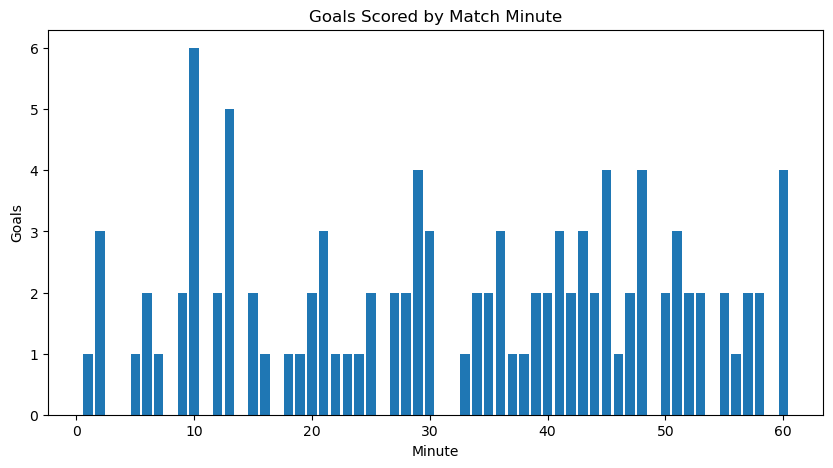

In [26]:
# Cell 63 - Goal Distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    minute_summary["Minute"],
    minute_summary["Goals"]
)

plt.xlabel("Minute")
plt.ylabel("Goals")
plt.title("Goals Scored by Match Minute")

plt.show()

In [27]:
# Cell 64 - Top Goalscorers

top_scorers_by_player = (
    goals
    .groupby(["Competition", "Player"])
    .size()
    .reset_index(name="Goals")
    .sort_values(
        ["Competition", "Goals"],
        ascending=[True, False]
    )
)

top_scorers_by_player


,Competition,Player,Goals
38,PLM,Mathias Gularire,6
26,PLM,Job Wandera,4
36,PLM,Malack Masese,4
42,PLM,Robert Masibo,4
6,PLM,Calvins Kanu Omondi,3
...,...,...,...
60,PLW,Mitchell Akoth,1
61,PLW,Nichole Joy,1
62,PLW,Noela Kimathi,1
63,PLW,Vivian Onyango,1


In [28]:
# Cell 66 - Top Scorers by Team

top_team_scorers = (
    goals
    .groupby(["Competition", "Team", "Player"])
    .size()
    .reset_index(name="Goals")
    .sort_values(
        ["Competition", "Team", "Goals"],
        ascending=[True, True, False]
    )
)

top_team_scorers


,Competition,Team,Player,Goals
0,PLM,Daikyo Heroes,Bonny Ndombi,2
1,PLM,Daikyo Heroes,Esbon Ombui,2
2,PLM,Daikyo Heroes,Farhan Khan,2
3,PLM,Daikyo Heroes,Joseph Kasua,1
4,PLM,Daikyo Heroes,Khizar Akhtar,1
...,...,...,...,...
60,PLW,UON Ladies,Clementine Sims,1
61,PLW,UON Ladies,Mitchell Akoth,1
62,PLW,UON Ladies,Noela Kimathi,1
64,PLW,USIU – A Ladies,Lynn Mwangi,2


In [29]:
# Cell 67 - Save Team Scorers

top_team_scorers.to_csv(
    "../data/processed/team_scorers.csv",
    index=False
)

print("Team scorers saved.")

Team scorers saved.


## Attack, Defence & Form Analysis

Home vs away splits, attacking/defensive rankings, and recent-form tracking.

In [30]:
# Cell 68 - Home vs Away Performance

home_away_summary = (
    results
    .groupby(["Competition", "Team", "Venue"])
    .agg(
        Played=("Team", "count"),
        Wins=("Win", "sum"),
        Draws=("Draw", "sum"),
        Losses=("Loss", "sum"),
        GF=("GF", "sum"),
        GA=("GA", "sum"),
        Points=("Points", "sum")
    )
    .reset_index()
)

home_away_summary


,Competition,Team,Venue,Played,Wins,Draws,Losses,GF,GA,Points
0,NLM-CZ,Dukes of Gloucester,Away,2,0,0,2,1,17,0
1,NLM-CZ,Dukes of Gloucester,Home,1,1,0,0,5,0,3
2,NLM-CZ,GHF Rift Pirates Men,Home,1,1,0,0,9,1,3
3,NLM-CZ,Nyari Hockey Club,Away,1,0,0,1,0,5,0
4,NLM-CZ,Thika Rovers,Home,1,1,0,0,8,0,3
...,...,...,...,...,...,...,...,...,...,...
111,SLW,Swans Hockey Club,Home,4,1,2,1,4,4,5
112,SLW,Twinkle Hockey Club,Away,4,3,1,0,11,3,10
113,SLW,Twinkle Hockey Club,Home,1,1,0,0,2,0,3
114,SLW,Wazalendo Pearls,Away,3,2,1,0,6,2,7


In [31]:
# Cell 69 - Save Home Away Summary

home_away_summary.to_csv(
    "../data/processed/home_away_by_venue.csv",
    index=False
)

print("Home/Away summary saved.")

Home/Away summary saved.


In [32]:
# Cell 70 - Defensive Ranking

defence = (
    results
    .groupby(["Competition", "Team"])
    .agg(
        GoalsConceded=("GA", "sum"),
        Matches=("Team", "count")
    )
    .reset_index()
)

defence["GoalsPerGame"] = (
    defence["GoalsConceded"] /
    defence["Matches"]
)

defence = defence.sort_values(
    ["Competition", "GoalsPerGame"],
    ascending=[True, True]
)

defence


,Competition,Team,GoalsConceded,Matches,GoalsPerGame
3,NLM-CZ,Thika Rovers,0,1,0.000000
1,NLM-CZ,GHF Rift Pirates Men,1,1,1.000000
2,NLM-CZ,Nyari Hockey Club,5,1,5.000000
0,NLM-CZ,Dukes of Gloucester,17,3,5.666667
12,NLM-EZ,Ulinzi Patriots,8,8,1.000000
...,...,...,...,...,...
56,SLW,GHF Rift Pirates Ladies,7,6,1.166667
59,SLW,Mombasa Sports Club Ladies,5,4,1.250000
55,SLW,Daystar University Ladies,9,5,1.800000
57,SLW,Gorillas Hockey Club – Ladies,6,3,2.000000


In [33]:
# Cell 71 - Save Defensive Ranking

defence.to_csv(
    "../data/processed/defensive_ranking.csv",
    index=False
)

print("Defensive ranking saved.")


Defensive ranking saved.


In [34]:
# Cell 72 - Attacking Ranking

attack = (
    results
    .groupby(["Competition", "Team"])
    .agg(
        GoalsScored=("GF", "sum"),
        Matches=("Team", "count")
    )
    .reset_index()
)

attack["GoalsPerGame"] = (
    attack["GoalsScored"] /
    attack["Matches"]
)

attack = attack.sort_values(
    ["Competition", "GoalsPerGame"],
    ascending=[True, False]
)

attack


,Competition,Team,GoalsScored,Matches,GoalsPerGame
1,NLM-CZ,GHF Rift Pirates Men,9,1,9.000000
3,NLM-CZ,Thika Rovers,8,1,8.000000
0,NLM-CZ,Dukes of Gloucester,6,3,2.000000
2,NLM-CZ,Nyari Hockey Club,0,1,0.000000
11,NLM-EZ,TUK Men,4,2,2.000000
...,...,...,...,...,...
60,SLW,Swans Hockey Club,4,4,1.000000
59,SLW,Mombasa Sports Club Ladies,3,4,0.750000
57,SLW,Gorillas Hockey Club – Ladies,2,3,0.666667
55,SLW,Daystar University Ladies,3,5,0.600000


In [35]:
# Cell 73 - Attack vs Defence (Improved)

attack_defence = attack.merge(
    defence[["Competition", "Team", "GoalsConceded", "GoalsPerGame"]],
    on=["Competition", "Team"],
    suffixes=("_x", "_y")
)

attack_defence = attack_defence.rename(
    columns={
        "GoalsPerGame_x": "GoalsScoredPerGame",
        "GoalsPerGame_y": "GoalsConcededPerGame"
    }
)

attack_defence


,Competition,Team,GoalsScored,Matches,GoalsScoredPerGame,GoalsConceded,GoalsConcededPerGame
0,NLM-CZ,GHF Rift Pirates Men,9,1,9.000000,1,1.000000
1,NLM-CZ,Thika Rovers,8,1,8.000000,0,0.000000
2,NLM-CZ,Dukes of Gloucester,6,3,2.000000,17,5.666667
3,NLM-CZ,Nyari Hockey Club,0,1,0.000000,5,5.000000
4,NLM-EZ,TUK Men,4,2,2.000000,4,2.000000
...,...,...,...,...,...,...,...
58,SLW,Swans Hockey Club,4,4,1.000000,4,1.000000
59,SLW,Mombasa Sports Club Ladies,3,4,0.750000,5,1.250000
60,SLW,Gorillas Hockey Club – Ladies,2,3,0.666667,6,2.000000
61,SLW,Daystar University Ladies,3,5,0.600000,9,1.800000


In [36]:
# Cell 74 - Save Attack vs Defence

attack_defence.to_csv(
    "../data/processed/attack_defence.csv",
    index=False
)

print("Attack vs Defence saved.")


Attack vs Defence saved.


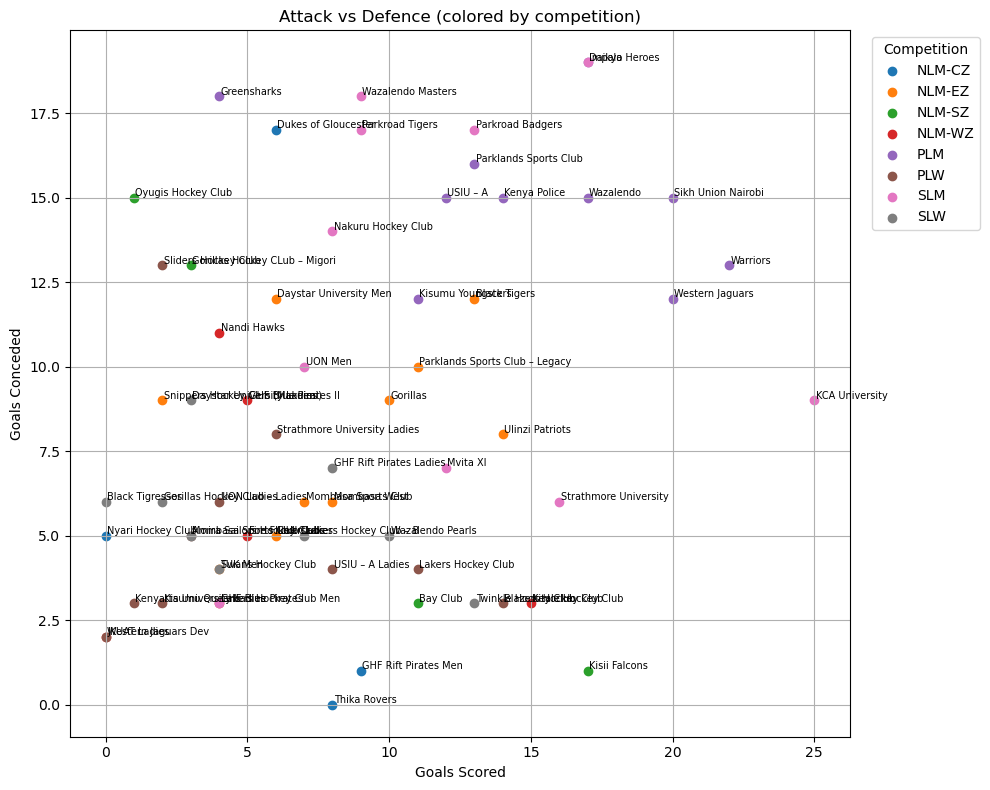

In [37]:
# Cell 75 - Goals Scored vs Goals Conceded

import matplotlib.pyplot as plt

competitions = attack_defence["Competition"].unique()
colors = plt.cm.tab10(range(len(competitions)))
color_map = dict(zip(competitions, colors))

plt.figure(figsize=(10, 8))

for comp in competitions:
    subset = attack_defence[attack_defence["Competition"] == comp]
    plt.scatter(
        subset["GoalsScored"],
        subset["GoalsConceded"],
        label=comp,
        color=color_map[comp]
    )

for _, row in attack_defence.iterrows():
    plt.text(
        row["GoalsScored"] + 0.05,
        row["GoalsConceded"] + 0.05,
        row["Team"],
        fontsize=7
    )

plt.xlabel("Goals Scored")
plt.ylabel("Goals Conceded")
plt.title("Attack vs Defence (colored by competition)")

plt.legend(title="Competition", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()

plt.show()


In [38]:
# Cell 76 - Goals Per Game Ranking

attack.sort_values(
    "GoalsPerGame",
    ascending=False
)

,Competition,Team,GoalsScored,Matches,GoalsPerGame
1,NLM-CZ,GHF Rift Pirates Men,9,1,9.000000
3,NLM-CZ,Thika Rovers,8,1,8.000000
16,NLM-SZ,Kisii Falcons,17,3,5.666667
14,NLM-SZ,Bay Club,11,3,3.666667
46,SLM,KCA University,25,8,3.125000
...,...,...,...,...,...
40,PLW,Sliders Hockey Club,2,7,0.285714
23,NLM-WZ,Western Jaguars Dev,0,1,0.000000
2,NLM-CZ,Nyari Hockey Club,0,1,0.000000
36,PLW,JKUAT Ladies,0,1,0.000000


In [39]:
# Cell 77 - Defensive Ranking (recap, sorted best-to-worst)

defence.sort_values(
    "GoalsPerGame"
)

,Competition,Team,GoalsConceded,Matches,GoalsPerGame
3,NLM-CZ,Thika Rovers,0,1,0.000000
16,NLM-SZ,Kisii Falcons,1,3,0.333333
35,PLW,Blazers Hockey Club,3,7,0.428571
43,PLW,USIU – A Ladies,4,8,0.500000
20,NLM-WZ,Kitale Hockey Club,3,5,0.600000
...,...,...,...,...,...
15,NLM-SZ,Gorillas Hockey CLub – Migori,13,3,4.333333
17,NLM-SZ,Oyugis Hockey Club,15,3,5.000000
2,NLM-CZ,Nyari Hockey Club,5,1,5.000000
0,NLM-CZ,Dukes of Gloucester,17,3,5.666667


In [40]:
# Cell 78 - Team Form Dataset

# Bring the match date back into the results dataframe

home_form = matches_df[
    ["Competition", "Date", "HomeTeam", "AwayTeam", "HomeGoals", "AwayGoals"]
].copy()

home_form.rename(columns={
    "HomeTeam":"Team",
    "AwayTeam":"Opponent",
    "HomeGoals":"GF",
    "AwayGoals":"GA"
}, inplace=True)

home_form["Venue"] = "Home"


away_form = matches_df[
    ["Competition", "Date", "HomeTeam", "AwayTeam", "HomeGoals", "AwayGoals"]
].copy()

away_form.rename(columns={
    "AwayTeam":"Team",
    "HomeTeam":"Opponent",
    "AwayGoals":"GF",
    "HomeGoals":"GA"
}, inplace=True)

away_form["Venue"] = "Away"


results_form = pd.concat(
    [home_form, away_form],
    ignore_index=True
)

results_form["Win"] = (results_form["GF"] > results_form["GA"]).astype(int)
results_form["Draw"] = (results_form["GF"] == results_form["GA"]).astype(int)
results_form["Loss"] = (results_form["GF"] < results_form["GA"]).astype(int)

results_form["Points"] = (
    results_form["Win"]*3 +
    results_form["Draw"]
)

results_form["Date"] = pd.to_datetime(
    results_form["Date"],
    dayfirst=True
)

results_form = results_form.sort_values(
    ["Competition", "Team", "Date"]
)

results_form.head()


,Competition,Date,Team,Opponent,GF,GA,Venue,Win,Draw,Loss,Points
157,NLM-CZ,2026-06-06,Dukes of Gloucester,Nyari Hockey Club,5,0,Home,1,0,0,3
336,NLM-CZ,2026-06-07,Dukes of Gloucester,Thika Rovers,0,8,Away,0,0,1,0
335,NLM-CZ,2026-06-21,Dukes of Gloucester,GHF Rift Pirates Men,1,9,Away,0,0,1,0
158,NLM-CZ,2026-06-21,GHF Rift Pirates Men,Dukes of Gloucester,9,1,Home,1,0,0,3
334,NLM-CZ,2026-06-06,Nyari Hockey Club,Dukes of Gloucester,0,5,Away,0,0,1,0


In [41]:
# Cell 79 - Last Five Form

results_form["Last5Points"] = (
    results_form
    .groupby(["Competition", "Team"])["Points"]
    .rolling(5)
    .sum()
    .reset_index(level=[0, 1], drop=True)
)

results_form.tail(15)


,Competition,Date,Team,Opponent,GF,GA,Venue,Win,Draw,Loss,Points,Last5Points
120,SLW,2026-06-06,Swans Hockey Club,Mombasa Sports Club Ladies,1,1,Home,0,1,0,1,NaN
121,SLW,2026-06-20,Swans Hockey Club,Wazalendo Pearls,1,1,Home,0,1,0,1,NaN
119,SLW,2026-07-18,Swans Hockey Club,Lakers Hockey Club – B,0,1,Home,0,0,1,0,NaN
118,SLW,2026-07-19,Swans Hockey Club,GHF Rift Pirates Ladies,2,1,Home,1,0,0,3,NaN
283,SLW,2026-06-06,Twinkle Hockey Club,Black Tigresses,6,0,Away,1,0,0,3,NaN
302,SLW,2026-06-07,Twinkle Hockey Club,Wazalendo Pearls,1,0,Away,1,0,0,3,NaN
293,SLW,2026-06-20,Twinkle Hockey Club,Lakers Hockey Club – B,3,3,Away,0,1,0,1,NaN
290,SLW,2026-06-21,Twinkle Hockey Club,GHF Rift Pirates Ladies,1,0,Away,1,0,0,3,NaN
122,SLW,2026-07-05,Twinkle Hockey Club,Daystar University Ladies,2,0,Home,1,0,0,3,13.0
125,SLW,2026-06-07,Wazalendo Pearls,Twinkle Hockey Club,0,1,Home,0,0,1,0,NaN


In [42]:
# Cell 80 - Save Form Dataset

results_form.to_csv(
    "../data/processed/team_form.csv",
    index=False
)

print("Team form dataset saved.")

Team form dataset saved.


In [43]:
# Cell 81 - Home vs Away Record

venue_summary = (
    results_form
    .groupby(["Competition", "Team", "Venue"])
    .agg(
        Played=("Team", "count"),
        Wins=("Win", "sum"),
        Draws=("Draw", "sum"),
        Losses=("Loss", "sum"),
        GF=("GF", "sum"),
        GA=("GA", "sum"),
        Points=("Points", "sum")
    )
    .reset_index()
)

venue_summary


,Competition,Team,Venue,Played,Wins,Draws,Losses,GF,GA,Points
0,NLM-CZ,Dukes of Gloucester,Away,2,0,0,2,1,17,0
1,NLM-CZ,Dukes of Gloucester,Home,1,1,0,0,5,0,3
2,NLM-CZ,GHF Rift Pirates Men,Home,1,1,0,0,9,1,3
3,NLM-CZ,Nyari Hockey Club,Away,1,0,0,1,0,5,0
4,NLM-CZ,Thika Rovers,Home,1,1,0,0,8,0,3
...,...,...,...,...,...,...,...,...,...,...
111,SLW,Swans Hockey Club,Home,4,1,2,1,4,4,5
112,SLW,Twinkle Hockey Club,Away,4,3,1,0,11,3,10
113,SLW,Twinkle Hockey Club,Home,1,1,0,0,2,0,3
114,SLW,Wazalendo Pearls,Away,3,2,1,0,6,2,7


In [44]:
# Cell 82 - Save Home Away Summary

venue_summary.to_csv(
    "../data/processed/home_away_by_venue_v2.csv",
    index=False
)

print("Home/Away summary saved.")

Home/Away summary saved.


## Match-Level Summaries & Visualizations

Highest-scoring matches, clean sheets, failed-to-score records, and league-wide charts.

In [45]:
# Cell 83 - Match Goal Totals

matches_df["TotalGoals"] = (
    matches_df["HomeGoals"] +
    matches_df["AwayGoals"]
)

matches_df[
    [
        "HomeTeam",
        "AwayTeam",
        "HomeGoals",
        "AwayGoals",
        "TotalGoals"
    ]
].head()

,HomeTeam,AwayTeam,HomeGoals,AwayGoals,TotalGoals
0,Amira Sailors Hockey Club,Blazers Hockey Club,0,3,3
1,Amira Sailors Hockey Club,Sliders Hockey Club,0,0,0
2,Blazers Hockey Club,Kenyatta University Ladies,2,0,2
3,Blazers Hockey Club,Kisumu Queens,1,0,1
4,Blazers Hockey Club,Sliders Hockey Club,3,0,3


In [46]:
# Cell 84 - Highest Scoring Matches

highest_scoring = (
    matches_df
    .sort_values(
        "TotalGoals",
        ascending=False
    )
)

highest_scoring[
    [
        "HomeTeam",
        "AwayTeam",
        "HomeGoals",
        "AwayGoals",
        "TotalGoals"
    ]
]

,HomeTeam,AwayTeam,HomeGoals,AwayGoals,TotalGoals
176,Oyugis Hockey Club,Kisii Falcons,0,10,10
158,GHF Rift Pirates Men,Dukes of Gloucester,9,1,10
50,Sikh Union Nairobi,Daikyo Heroes,6,3,9
159,Thika Rovers,Dukes of Gloucester,8,0,8
172,Gorillas Hockey CLub – Migori,Bay Club,0,8,8
...,...,...,...,...,...
1,Amira Sailors Hockey Club,Sliders Hockey Club,0,0,0
152,Ulinzi Patriots,Mombasa West,0,0,0
115,Lakers Hockey Club – B,Mombasa Sports Club Ladies,0,0,0
6,Kisumu Queens,Amira Sailors Hockey Club,0,0,0


In [47]:
# Cell 85 - Save Highest Scoring Matches

highest_scoring.to_csv(
    "../data/processed/highest_scoring_matches.csv",
    index=False
)

print("Highest scoring matches saved.")

Highest scoring matches saved.


In [48]:
# Cell 86 - Team Clean Sheets

clean_sheets = (
    results_form
    .assign(CleanSheet=(results_form["GA"] == 0).astype(int))
    .groupby(["Competition", "Team"])
    .agg(
        CleanSheets=("CleanSheet", "sum"),
        Matches=("Team", "count")
    )
    .reset_index()
)

clean_sheets["CleanSheetRate"] = (
    clean_sheets["CleanSheets"] /
    clean_sheets["Matches"]
).round(2)

clean_sheets.sort_values(
    ["Competition", "CleanSheets"],
    ascending=[True, False]
)


,Competition,Team,CleanSheets,Matches,CleanSheetRate
0,NLM-CZ,Dukes of Gloucester,1,3,0.33
3,NLM-CZ,Thika Rovers,1,1,1.00
1,NLM-CZ,GHF Rift Pirates Men,0,1,0.00
2,NLM-CZ,Nyari Hockey Club,0,1,0.00
4,NLM-EZ,Black Tigers,2,9,0.22
...,...,...,...,...,...
62,SLW,Wazalendo Pearls,1,6,0.17
54,SLW,Black Tigresses,0,1,0.00
55,SLW,Daystar University Ladies,0,5,0.00
57,SLW,Gorillas Hockey Club – Ladies,0,3,0.00


In [49]:
# Cell 87 - Save Clean Sheets

clean_sheets.to_csv(
    "../data/processed/clean_sheets.csv"
)

print("Clean sheets saved.")

Clean sheets saved.


In [50]:
# Cell 88 - Failed To Score

failed_to_score = (
    results_form
    .assign(FailedToScore=(results_form["GF"] == 0).astype(int))
    .groupby(["Competition", "Team"])
    .agg(
        FailedToScore=("FailedToScore", "sum"),
        Matches=("Team", "count")
    )
    .reset_index()
)

failed_to_score["Rate"] = (
    failed_to_score["FailedToScore"] /
    failed_to_score["Matches"]
).round(2)

failed_to_score.sort_values(
    ["Competition", "FailedToScore"],
    ascending=[True, False]
)


,Competition,Team,FailedToScore,Matches,Rate
0,NLM-CZ,Dukes of Gloucester,1,3,0.33
2,NLM-CZ,Nyari Hockey Club,1,1,1.00
1,NLM-CZ,GHF Rift Pirates Men,0,1,0.00
3,NLM-CZ,Thika Rovers,0,1,0.00
10,NLM-EZ,Snippers Hockey Club (Makueni),4,6,0.67
...,...,...,...,...,...
58,SLW,Lakers Hockey Club – B,1,6,0.17
59,SLW,Mombasa Sports Club Ladies,1,4,0.25
60,SLW,Swans Hockey Club,1,4,0.25
62,SLW,Wazalendo Pearls,1,6,0.17


In [51]:
# Cell 89 - Save Failed To Score

failed_to_score.to_csv(
    "../data/processed/failed_to_score.csv"
)

print("Failed-to-score summary saved.")

Failed-to-score summary saved.


In [52]:
# Cell 90 - League Goal Average

league_average = pd.DataFrame({

    "Statistic": [
        "Matches",
        "Total Goals",
        "Average Goals Per Match"
    ],

    "Value": [

        len(matches_df),

        matches_df["TotalGoals"].sum(),

        round(matches_df["TotalGoals"].mean(), 2)

    ]

})

league_average

,Statistic,Value
0,Matches,177.00
1,Total Goals,540.00
2,Average Goals Per Match,3.05


In [53]:
# Cell 91 - Visualization Libraries

import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 11

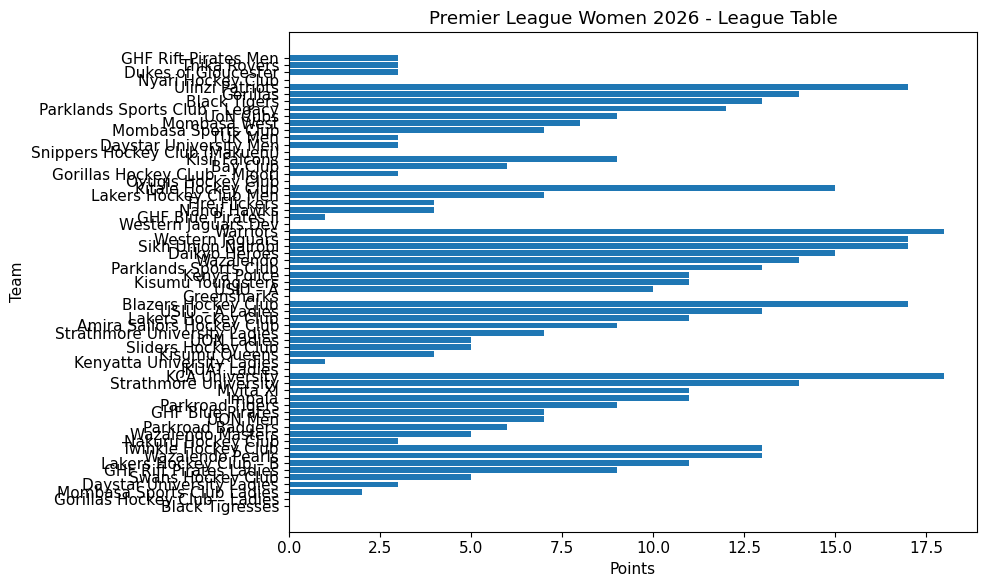

In [54]:
# Cell 92 - League Table Chart

plt.figure()

plt.barh(
    league_table["Team"],
    league_table["Points"]
)

plt.gca().invert_yaxis()

plt.xlabel("Points")
plt.ylabel("Team")
plt.title("Premier League Women 2026 - League Table")

plt.tight_layout()

plt.show()

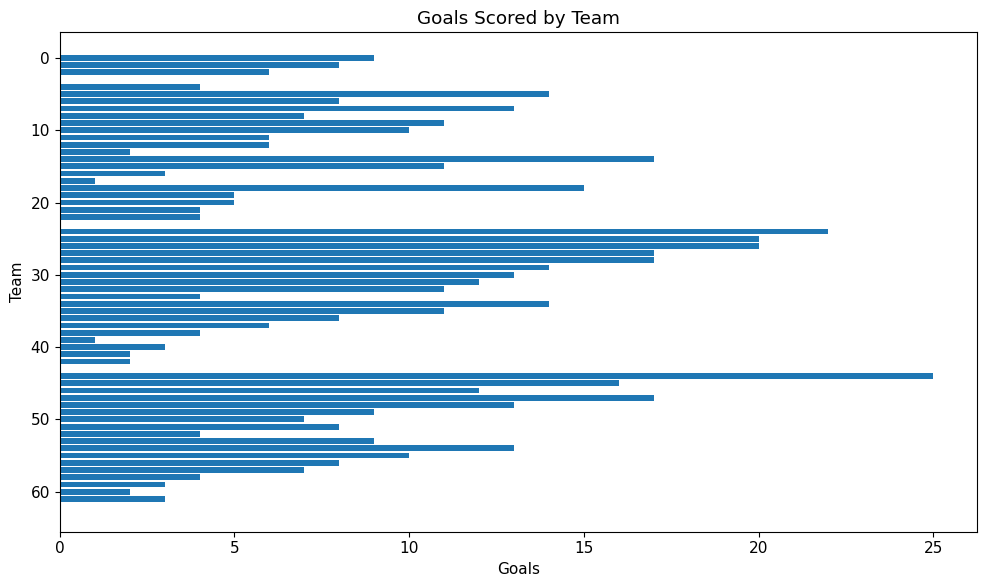

In [55]:
# Cell 93 - Goals Scored

plt.figure()

plt.barh(
    attack_defence.index,
    attack_defence["GoalsScored"]
)

plt.gca().invert_yaxis()

plt.xlabel("Goals")
plt.ylabel("Team")
plt.title("Goals Scored by Team")

plt.tight_layout()

plt.show()

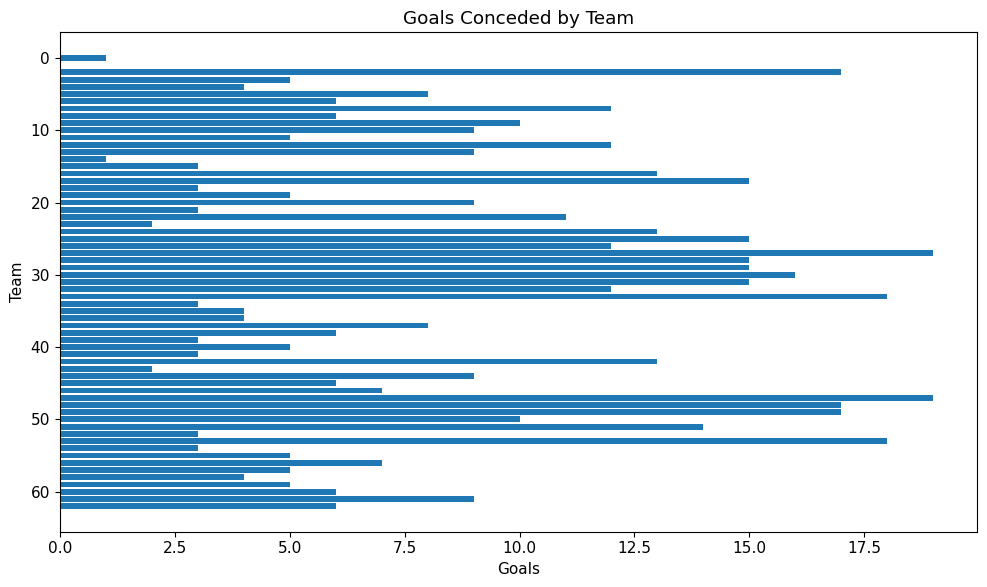

In [56]:
# Cell 94 - Goals Conceded

plt.figure()

plt.barh(
    attack_defence.index,
    attack_defence["GoalsConceded"]
)

plt.gca().invert_yaxis()

plt.xlabel("Goals")
plt.ylabel("Team")
plt.title("Goals Conceded by Team")

plt.tight_layout()

plt.show()

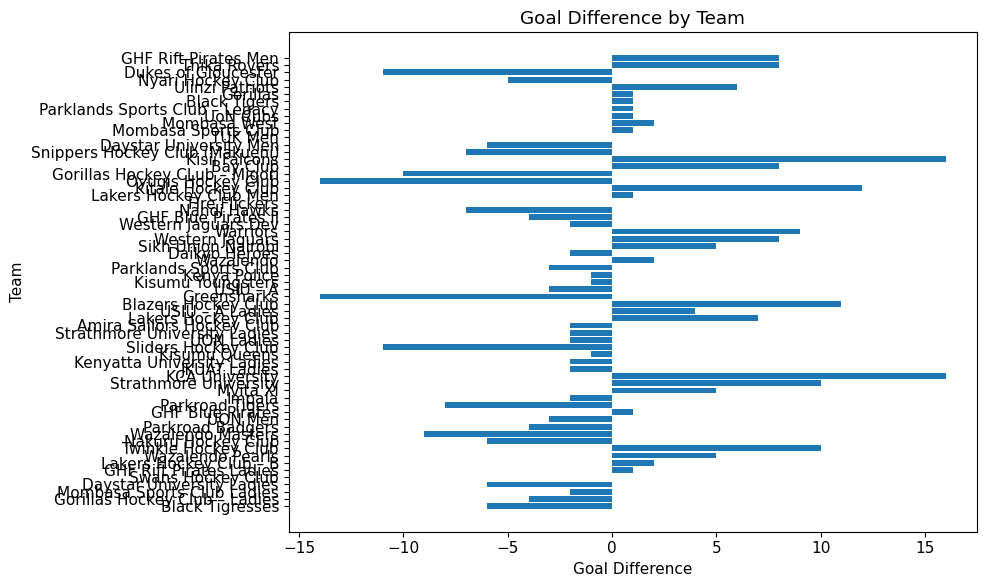

In [57]:
# Cell 95 - Goal Difference

plt.figure()

plt.barh(
    league_table["Team"],
    league_table["GD"]
)

plt.gca().invert_yaxis()

plt.xlabel("Goal Difference")
plt.ylabel("Team")
plt.title("Goal Difference by Team")

plt.tight_layout()

plt.show()

In [58]:
# cell 96A
print("goals exists:", "goals" in globals())
print("goal_summary exists:", "goal_summary" in globals())

goals exists: True
goal_summary exists: False


In [59]:
# Cell 96B - Goal Summary by Player

goal_summary = (
    goals
    .groupby(["Competition", "Player"])
    .size()
    .reset_index(name="Goals")
    .sort_values(
        ["Competition", "Goals"],
        ascending=[True, False]
    )
)

goal_summary


,Competition,Player,Goals
38,PLM,Mathias Gularire,6
26,PLM,Job Wandera,4
36,PLM,Malack Masese,4
42,PLM,Robert Masibo,4
6,PLM,Calvins Kanu Omondi,3
...,...,...,...
60,PLW,Mitchell Akoth,1
61,PLW,Nichole Joy,1
62,PLW,Noela Kimathi,1
63,PLW,Vivian Onyango,1


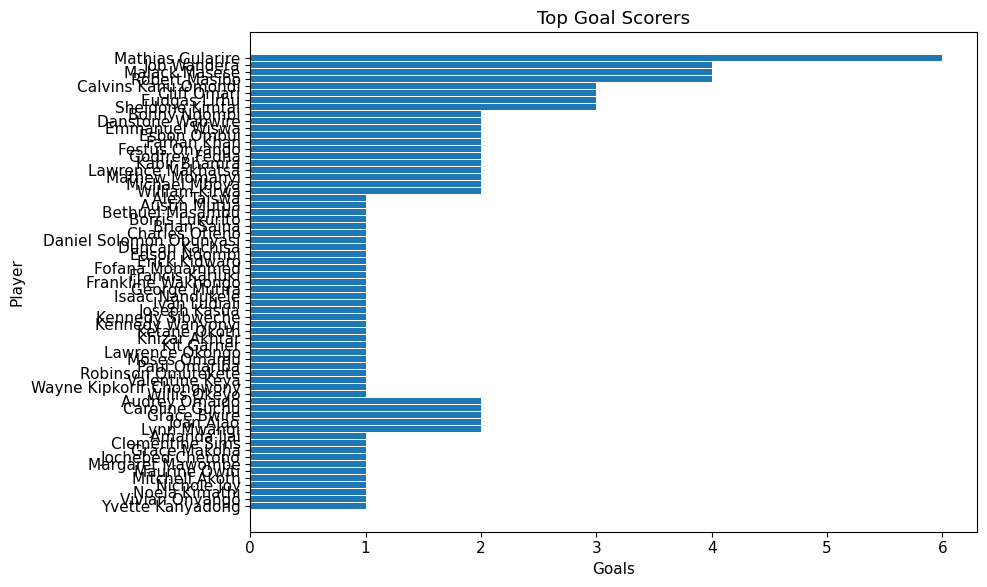

In [60]:
# Cell 96 - Top Goal Scorers

plt.figure()

plt.barh(
    goal_summary["Player"],
    goal_summary["Goals"]
)

plt.gca().invert_yaxis()

plt.xlabel("Goals")
plt.ylabel("Player")
plt.title("Top Goal Scorers")

plt.tight_layout()

plt.show()

In [61]:
# Cell 97 - Save Goal Summary

goal_summary.to_csv(
    "../data/processed/goal_summary.csv",
    index=False
)

print("Goal summary saved.")

Goal summary saved.


In [62]:
# Cell 98 - Top Carded Players

player_card_summary = (
    cards
    .groupby(["Competition", "Player", "Event"])
    .size()
    .reset_index(name="Cards")
    .sort_values(
        ["Competition", "Cards"],
        ascending=[True, False]
    )
)

player_card_summary


,Competition,Player,Event,Cards
9,PLM,Calvins Kanu Omondi,Green Card,3
32,PLM,Michael Mboya,Green Card,3
14,PLM,Duncan Kachisa,Green Card,2
16,PLM,Elvis Young Adala,Green Card,2
34,PLM,Moses Omamu,Green Card,2
41,PLM,Willis Malesi,Green Card,2
0,PLM,Allan Iningu,Green Card,1
1,PLM,Aredha Mandela,Green Card,1
2,PLM,Arjun Uupta,Green Card,1
3,PLM,Asher Ochieng,Green Card,1


In [63]:
# Cell 99 - Save Card Summary

player_card_summary.to_csv(
    "../data/processed/player_cards.csv",
    index=False
)

print("Player cards saved.")

Player cards saved.


In [64]:
# Cell 100 - Cards by Team

team_cards = (
    cards
    .groupby(["Competition", "Team"])
    .size()
    .reset_index(name="Cards")
    .sort_values(
        ["Competition", "Cards"],
        ascending=[True, False]
    )
)

team_cards


,Competition,Team,Cards
2,PLM,Kisumu Youngsters,9
3,PLM,Parklands Sports Club,9
6,PLM,Warriors,8
1,PLM,Greensharks,7
7,PLM,Wazalendo,6
4,PLM,Sikh Union Nairobi,4
8,PLM,Western Jaguars,4
5,PLM,USIU – A,3
0,PLM,Daikyo Heroes,2
9,PLW,Blazers Hockey Club,2


In [65]:
# Cell 101 - Save Team Cards

team_cards.to_csv(
    "../data/processed/team_cards.csv",
    index=False
)

print("Team cards saved.")

Team cards saved.


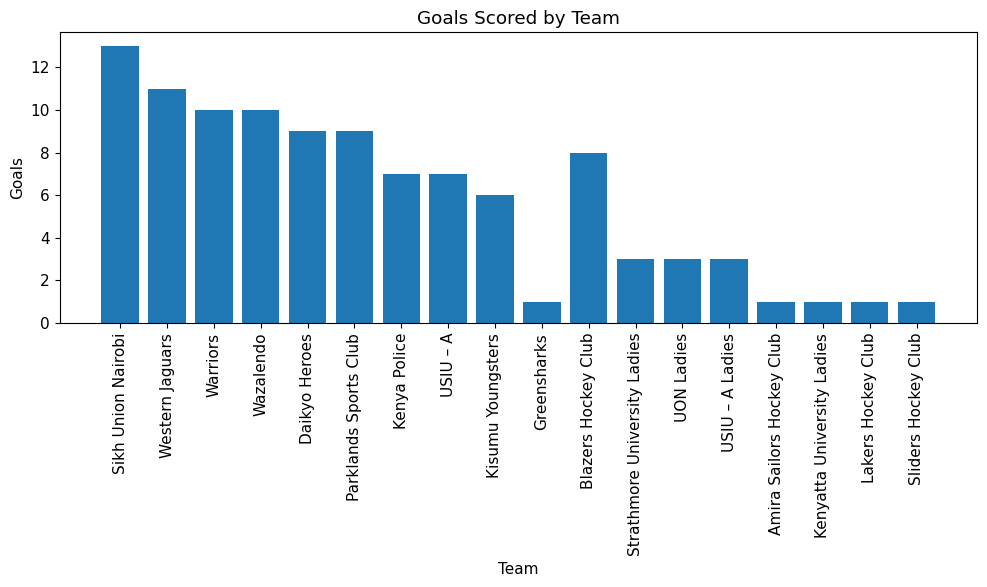

In [66]:
# cell 102

plt.figure(figsize=(10,6))

plt.bar(
    team_goals["Team"],
    team_goals["Goals"]
)

plt.xticks(rotation=90)

plt.ylabel("Goals")
plt.xlabel("Team")
plt.title("Goals Scored by Team")

plt.tight_layout()

plt.show()

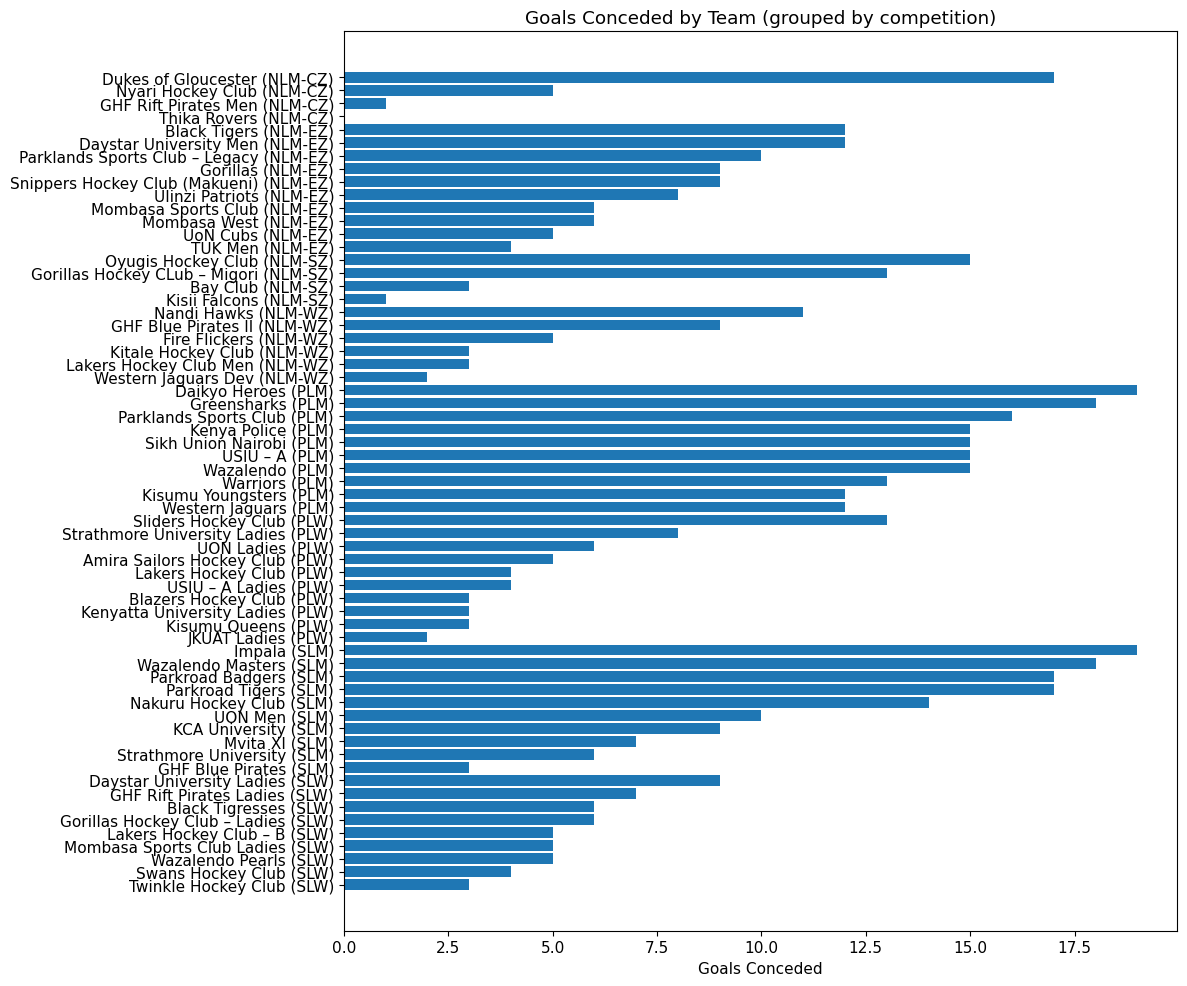

In [67]:
# Cell 103 - Goals Conceded by Team

goals_against = (
    results
    .groupby(["Competition", "Team"])["GA"]
    .sum()
    .reset_index()
    .sort_values(["Competition", "GA"], ascending=[True, False])
)

goals_against["Label"] = goals_against["Team"] + " (" + goals_against["Competition"] + ")"

plt.figure(figsize=(12, 10))

plt.barh(
    goals_against["Label"],
    goals_against["GA"]
)

plt.gca().invert_yaxis()
plt.xlabel("Goals Conceded")
plt.title("Goals Conceded by Team (grouped by competition)")

plt.tight_layout()
plt.show()


C:\Users\Administrator\AppData\Local\Temp\ipykernel_21700\3703238094.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["GF"].sum() - x["GA"].sum())


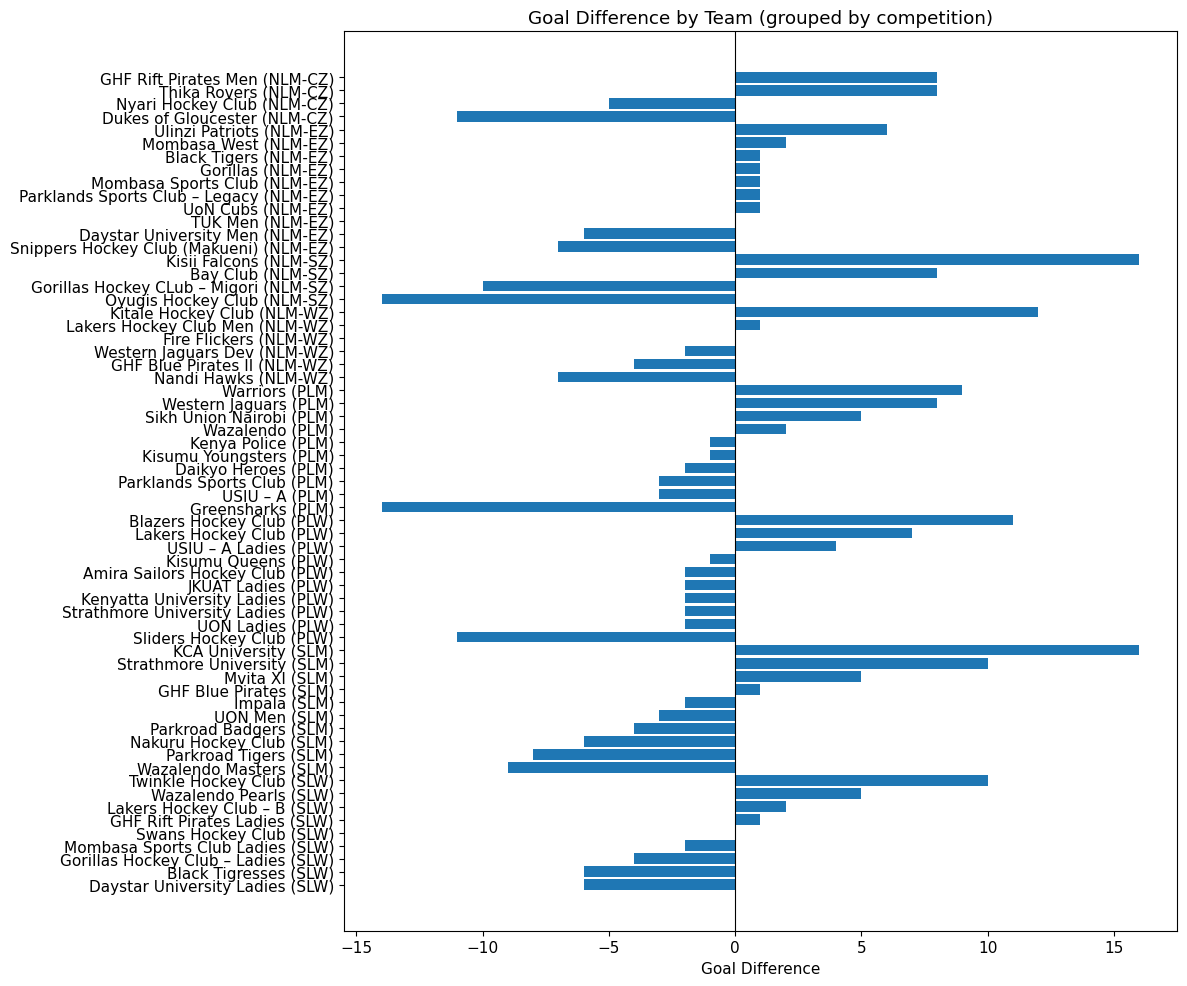

In [68]:
# Cell 104 - Goal Difference by Team

goal_difference = (
    results
    .groupby(["Competition", "Team"])
    .apply(lambda x: x["GF"].sum() - x["GA"].sum())
    .reset_index(name="GoalDifference")
    .sort_values(["Competition", "GoalDifference"], ascending=[True, False])
)

goal_difference["Label"] = goal_difference["Team"] + " (" + goal_difference["Competition"] + ")"

plt.figure(figsize=(12, 10))

plt.barh(
    goal_difference["Label"],
    goal_difference["GoalDifference"]
)

plt.gca().invert_yaxis()
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Goal Difference")
plt.title("Goal Difference by Team (grouped by competition)")

plt.tight_layout()
plt.show()


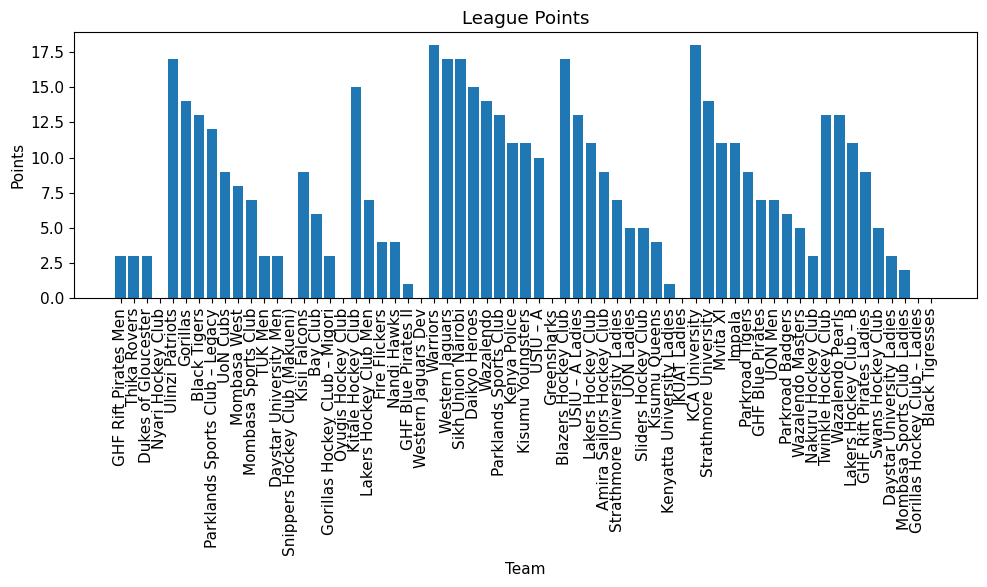

In [69]:
# cell 105

plt.figure(figsize=(10,6))

plt.bar(
    league_table["Team"],
    league_table["Points"]
)

plt.xticks(rotation=90)

plt.ylabel("Points")
plt.xlabel("Team")
plt.title("League Points")

plt.tight_layout()

plt.show()

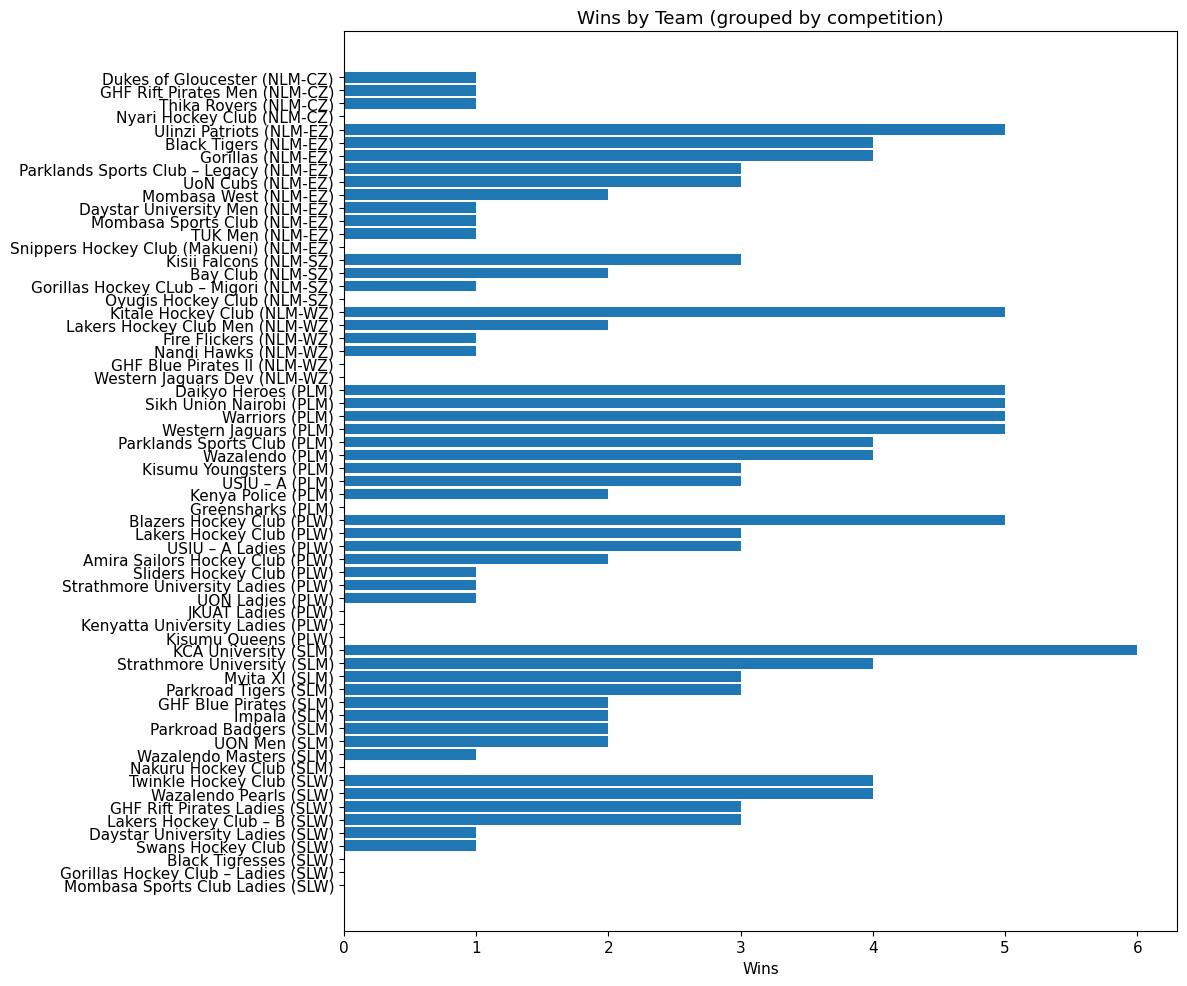

In [70]:
# Cell 106 - Wins by Team

wins = (
    results
    .groupby(["Competition", "Team"])["Win"]
    .sum()
    .reset_index()
    .sort_values(["Competition", "Win"], ascending=[True, False])
)

wins["Label"] = wins["Team"] + " (" + wins["Competition"] + ")"

plt.figure(figsize=(12, 10))

plt.barh(
    wins["Label"],
    wins["Win"]
)

plt.gca().invert_yaxis()
plt.xlabel("Wins")
plt.title("Wins by Team (grouped by competition)")

plt.tight_layout()
plt.show()


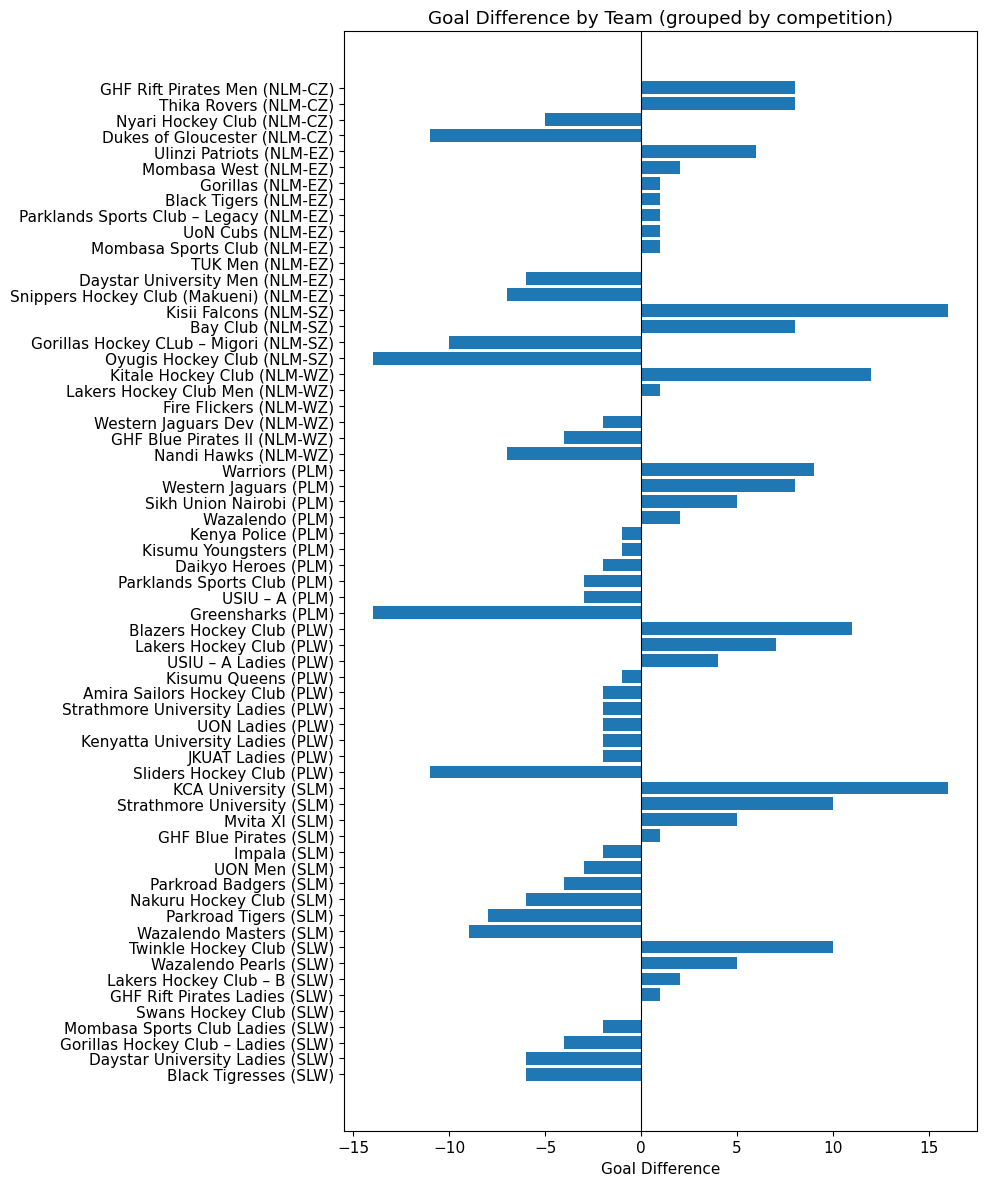

In [71]:
# Cell 107 - Team Goal Difference Chart

lt_sorted = league_table.sort_values(["Competition", "GD"], ascending=[True, False])
labels = lt_sorted["Team"] + " (" + lt_sorted["Competition"] + ")"

plt.figure(figsize=(10, 12))

plt.barh(
    labels,
    lt_sorted["GD"]
)

plt.gca().invert_yaxis()
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Goal Difference")
plt.title("Goal Difference by Team (grouped by competition)")

plt.tight_layout()
plt.show()


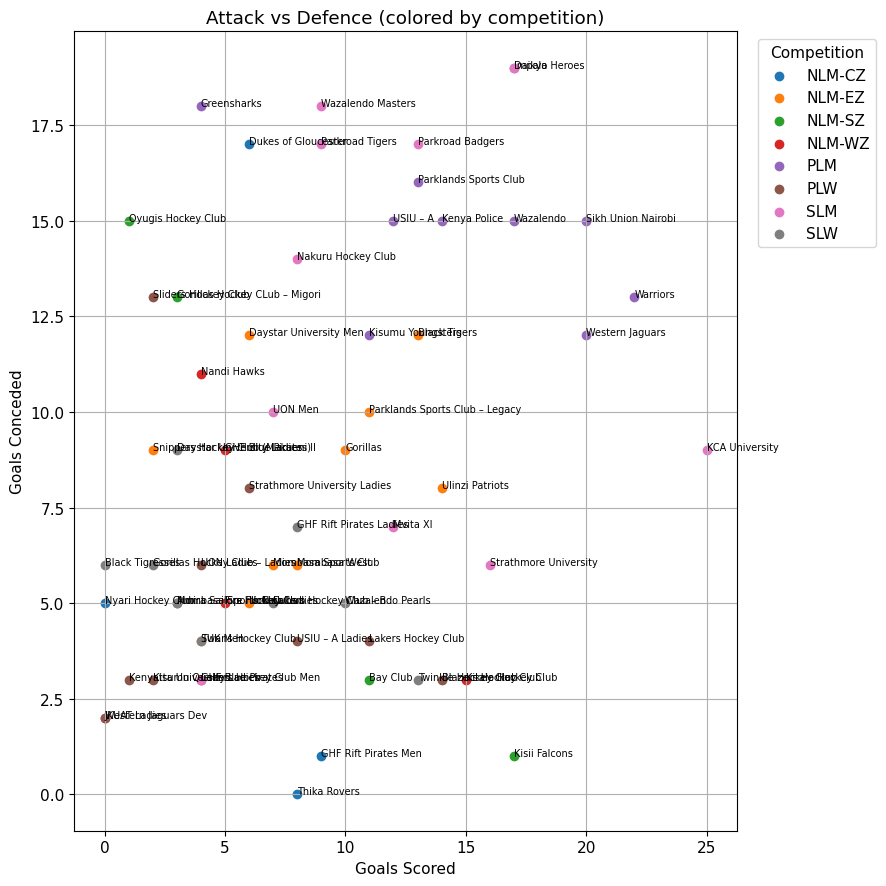

In [72]:
# Cell 108 - Goals For vs Goals Against

competitions = league_table["Competition"].unique()
colors = plt.cm.tab10(range(len(competitions)))
color_map = dict(zip(competitions, colors))

plt.figure(figsize=(9, 9))

for comp in competitions:
    subset = league_table[league_table["Competition"] == comp]
    plt.scatter(
        subset["GF"],
        subset["GA"],
        label=comp,
        color=color_map[comp]
    )

for _, row in league_table.iterrows():
    plt.text(
        row["GF"],
        row["GA"],
        row["Team"],
        fontsize=7
    )

plt.xlabel("Goals Scored")
plt.ylabel("Goals Conceded")
plt.title("Attack vs Defence (colored by competition)")

plt.legend(title="Competition", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()

plt.show()


In [73]:
# Cell 109 - Average Goals Per Match

league_table["GoalsPerMatch"] = (
    league_table["GF"] /
    league_table["Played"]
)

league_table[
    ["Competition", "Team", "GoalsPerMatch"]
].sort_values(
    ["Competition", "GoalsPerMatch"],
    ascending=[True, False]
)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_21700\4127999975.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  league_table["GoalsPerMatch"] = (


,Competition,Team,GoalsPerMatch
1,NLM-CZ,GHF Rift Pirates Men,9.000000
3,NLM-CZ,Thika Rovers,8.000000
0,NLM-CZ,Dukes of Gloucester,2.000000
2,NLM-CZ,Nyari Hockey Club,0.000000
11,NLM-EZ,TUK Men,2.000000
...,...,...,...
60,SLW,Swans Hockey Club,1.000000
59,SLW,Mombasa Sports Club Ladies,0.750000
57,SLW,Gorillas Hockey Club – Ladies,0.666667
55,SLW,Daystar University Ladies,0.600000


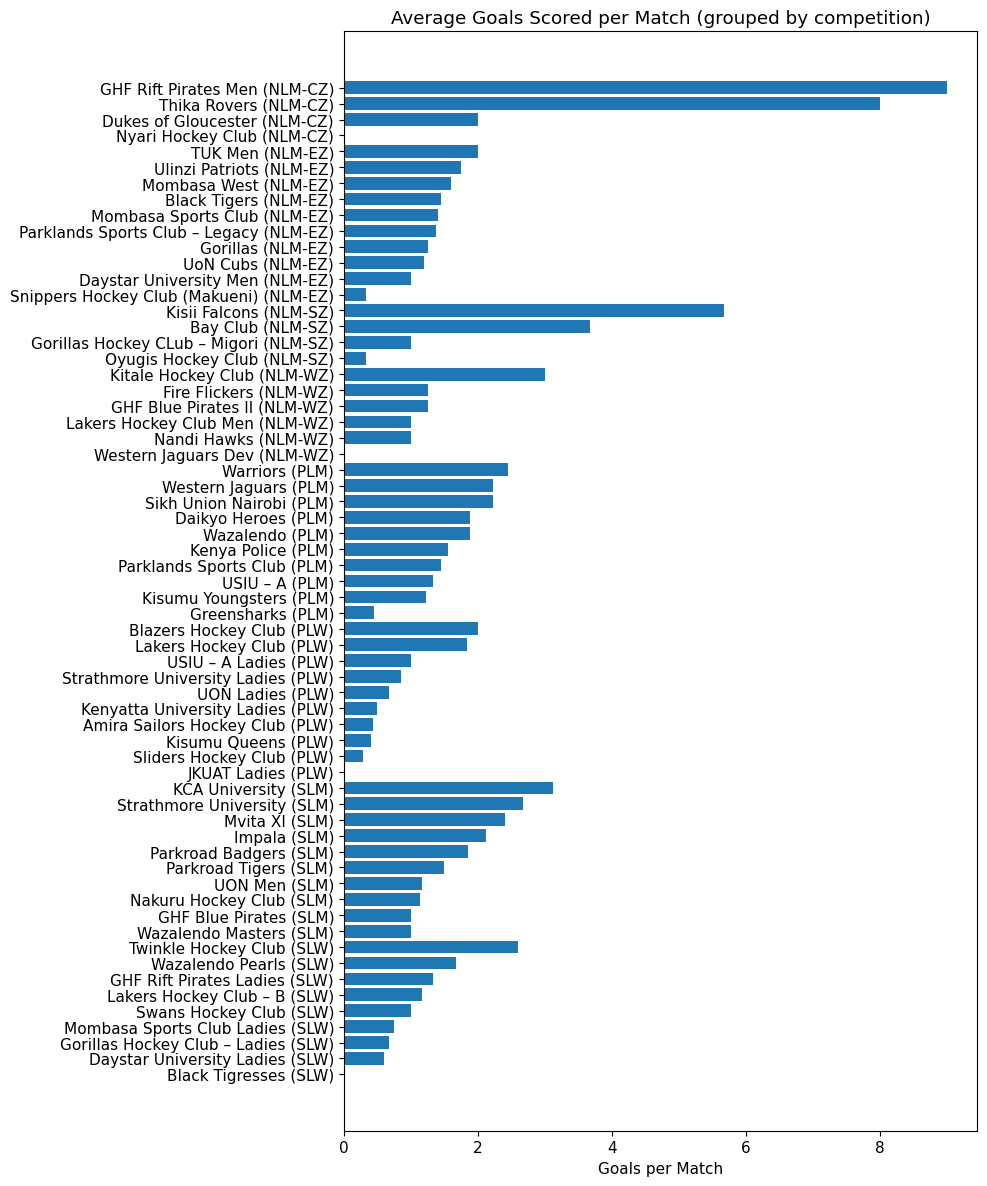

In [74]:
# Cell 110 - Plot Goals Per Match

gpm = league_table.sort_values(["Competition", "GoalsPerMatch"], ascending=[True, False])
labels = gpm["Team"] + " (" + gpm["Competition"] + ")"

plt.figure(figsize=(10, 12))

plt.barh(
    labels,
    gpm["GoalsPerMatch"]
)

plt.gca().invert_yaxis()
plt.xlabel("Goals per Match")
plt.title("Average Goals Scored per Match (grouped by competition)")

plt.tight_layout()
plt.show()


In [75]:
# Cell 111 - Defensive Strength

league_table["GoalsAgainstPerMatch"] = (
    league_table["GA"] /
    league_table["Played"]
)

league_table[
    ["Competition", "Team", "GoalsAgainstPerMatch"]
].sort_values(
    ["Competition", "GoalsAgainstPerMatch"],
    ascending=[True, True]
)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_21700\33038862.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  league_table["GoalsAgainstPerMatch"] = (


,Competition,Team,GoalsAgainstPerMatch
3,NLM-CZ,Thika Rovers,0.000000
1,NLM-CZ,GHF Rift Pirates Men,1.000000
2,NLM-CZ,Nyari Hockey Club,5.000000
0,NLM-CZ,Dukes of Gloucester,5.666667
12,NLM-EZ,Ulinzi Patriots,1.000000
...,...,...,...
56,SLW,GHF Rift Pirates Ladies,1.166667
59,SLW,Mombasa Sports Club Ladies,1.250000
55,SLW,Daystar University Ladies,1.800000
57,SLW,Gorillas Hockey Club – Ladies,2.000000


In [76]:
# Cell 112A - Check Columns

print(home_results.columns.tolist())
print()
print(results.columns.tolist())

['Competition', 'Team', 'Opponent', 'Venue', 'GF', 'GA']

['Competition', 'Team', 'Opponent', 'Venue', 'GF', 'GA', 'Win', 'Draw', 'Loss', 'Points']


In [77]:
# Cell 112B - Rebuild Home & Away Results

home_results = results[
    results["Venue"] == "Home"
].copy()

away_results = results[
    results["Venue"] == "Away"
].copy()

In [78]:
# Cell 112 - Home Performance

home_summary = (
    home_results
    .groupby(["Competition", "Team"])
    .agg(
        HomePlayed=("Team", "count"),
        HomeGF=("GF", "sum"),
        HomeGA=("GA", "sum"),
        HomeWins=("Win", "sum"),
        HomeDraws=("Draw", "sum"),
        HomeLosses=("Loss", "sum"),
        HomePoints=("Points", "sum")
    )
    .reset_index()
)

home_summary


,Competition,Team,HomePlayed,HomeGF,HomeGA,HomeWins,HomeDraws,HomeLosses,HomePoints
0,NLM-CZ,Dukes of Gloucester,1,5,0,1,0,0,3
1,NLM-CZ,GHF Rift Pirates Men,1,9,1,1,0,0,3
2,NLM-CZ,Thika Rovers,1,8,0,1,0,0,3
3,NLM-EZ,Black Tigers,4,7,3,3,0,1,9
4,NLM-EZ,Daystar University Men,3,3,6,0,0,3,0
5,NLM-EZ,Gorillas,5,4,6,1,2,2,5
6,NLM-EZ,Mombasa Sports Club,2,2,2,0,2,0,2
7,NLM-EZ,Mombasa West,3,6,5,1,1,1,4
8,NLM-EZ,Parklands Sports Club – Legacy,2,3,3,1,0,1,3
9,NLM-EZ,Snippers Hockey Club (Makueni),3,2,5,0,0,3,0


In [79]:
# Cell 113 - Away Performance

away_summary = (
    away_results
    .groupby(["Competition", "Team"])
    .agg(
        AwayPlayed=("Team", "count"),
        AwayGF=("GF", "sum"),
        AwayGA=("GA", "sum"),
        AwayWins=("Win", "sum"),
        AwayDraws=("Draw", "sum"),
        AwayLosses=("Loss", "sum"),
        AwayPoints=("Points", "sum")
    )
    .reset_index()
)

away_summary


,Competition,Team,AwayPlayed,AwayGF,AwayGA,AwayWins,AwayDraws,AwayLosses,AwayPoints
0,NLM-CZ,Dukes of Gloucester,2,1,17,0,0,2,0
1,NLM-CZ,Nyari Hockey Club,1,0,5,0,0,1,0
2,NLM-EZ,Black Tigers,5,6,9,1,1,3,4
3,NLM-EZ,Daystar University Men,3,3,6,1,0,2,3
4,NLM-EZ,Gorillas,3,6,3,3,0,0,9
5,NLM-EZ,Mombasa Sports Club,3,5,4,1,2,0,5
6,NLM-EZ,Mombasa West,2,2,1,1,1,0,4
7,NLM-EZ,Parklands Sports Club – Legacy,6,8,7,2,3,1,9
8,NLM-EZ,Snippers Hockey Club (Makueni),3,0,4,0,0,3,0
9,NLM-EZ,Ulinzi Patriots,3,6,2,3,0,0,9


In [80]:
# Cell 114 - Home vs Away Table

home_away = (
    home_summary
    .merge(
        away_summary,
        on=["Competition", "Team"]
    )
)

home_away


,Competition,Team,HomePlayed,HomeGF,HomeGA,HomeWins,HomeDraws,HomeLosses,HomePoints,AwayPlayed,AwayGF,AwayGA,AwayWins,AwayDraws,AwayLosses,AwayPoints
0,NLM-CZ,Dukes of Gloucester,1,5,0,1,0,0,3,2,1,17,0,0,2,0
1,NLM-EZ,Black Tigers,4,7,3,3,0,1,9,5,6,9,1,1,3,4
2,NLM-EZ,Daystar University Men,3,3,6,0,0,3,0,3,3,6,1,0,2,3
3,NLM-EZ,Gorillas,5,4,6,1,2,2,5,3,6,3,3,0,0,9
4,NLM-EZ,Mombasa Sports Club,2,2,2,0,2,0,2,3,5,4,1,2,0,5
5,NLM-EZ,Mombasa West,3,6,5,1,1,1,4,2,2,1,1,1,0,4
6,NLM-EZ,Parklands Sports Club – Legacy,2,3,3,1,0,1,3,6,8,7,2,3,1,9
7,NLM-EZ,Snippers Hockey Club (Makueni),3,2,5,0,0,3,0,3,0,4,0,0,3,0
8,NLM-EZ,Ulinzi Patriots,5,8,6,2,2,1,8,3,6,2,3,0,0,9
9,NLM-EZ,UoN Cubs,2,2,0,2,0,0,6,3,4,5,1,0,2,3


In [81]:
# Cell 115 - Save Home Away Summary

home_away.to_csv(
    "../data/processed/home_away_wide.csv",
    index=False
)

print("Home/Away summary saved.")


Home/Away summary saved.


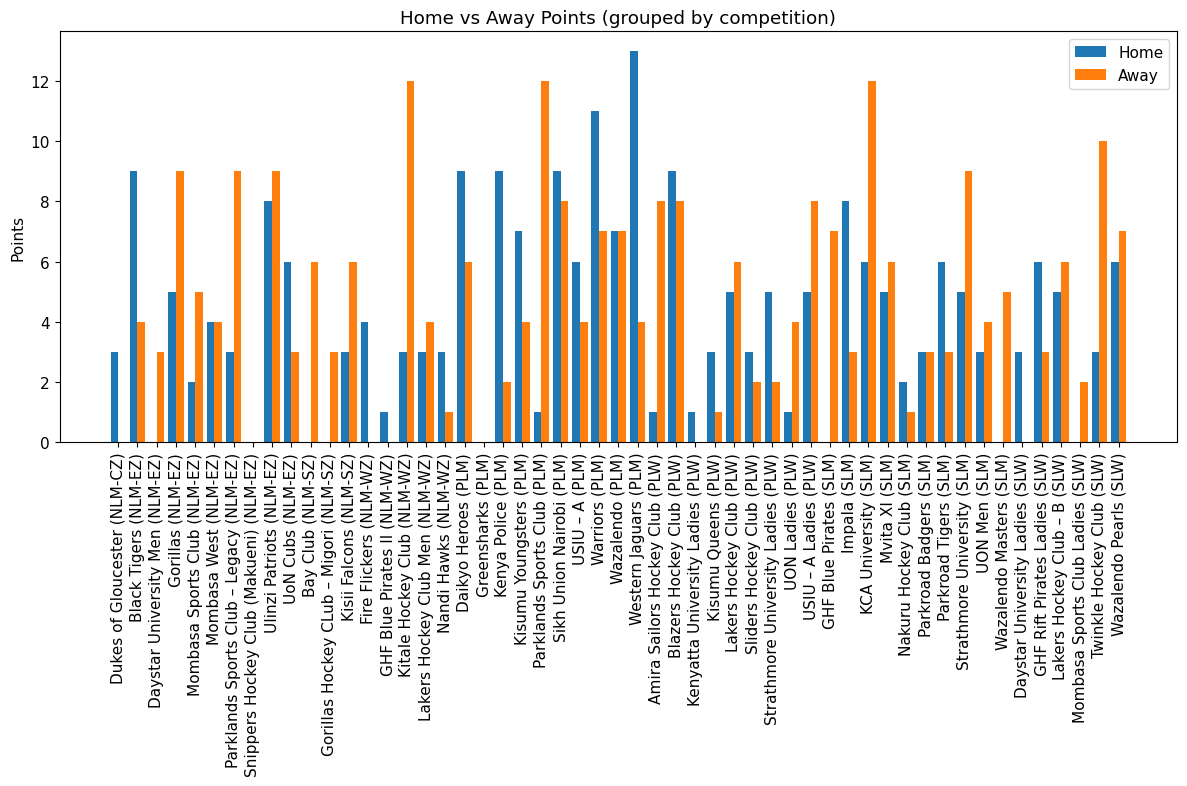

In [82]:
# Cell 116 - Home vs Away Points Chart

ha_sorted = home_away.sort_values(["Competition", "Team"]).reset_index(drop=True)
labels = ha_sorted["Team"] + " (" + ha_sorted["Competition"] + ")"

plt.figure(figsize=(12, 8))

x = range(len(ha_sorted))
width = 0.4

plt.bar(
    [i - width/2 for i in x],
    ha_sorted["HomePoints"],
    width=width,
    label="Home"
)

plt.bar(
    [i + width/2 for i in x],
    ha_sorted["AwayPoints"],
    width=width,
    label="Away"
)

plt.xticks(
    x,
    labels,
    rotation=90
)

plt.ylabel("Points")
plt.title("Home vs Away Points (grouped by competition)")

plt.legend()
plt.tight_layout()

plt.show()


## Home vs Away Detail & Final Exports

Detailed home/away breakdowns, goal distribution charts, and saving the consolidated `results_dataset.csv` / `performance_metrics.csv` used by the next notebook.

In [83]:
# Cell 117 - Save Home/Away Summary

venue_summary.to_csv(
    "../data/processed/home_away_summary.csv",
    index=False
)

print("Home/Away summary saved.")


Home/Away summary saved.


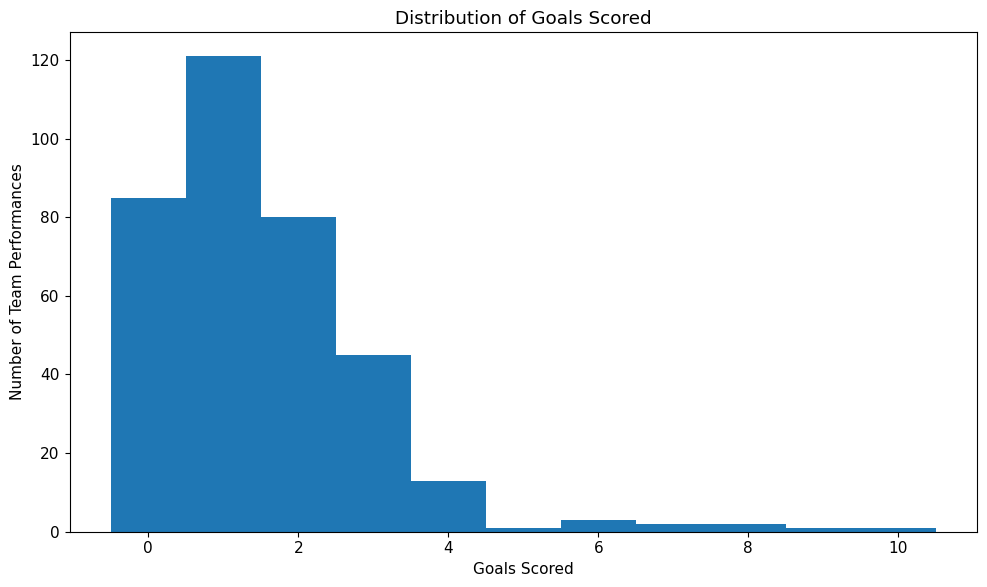

In [84]:
# Cell 118 - Goals Scored Distribution

plt.figure(figsize=(10,6))

plt.hist(
    results["GF"],
    bins=range(0, results["GF"].max()+2),
    align="left"
)

plt.xlabel("Goals Scored")
plt.ylabel("Number of Team Performances")
plt.title("Distribution of Goals Scored")

plt.tight_layout()
plt.show()

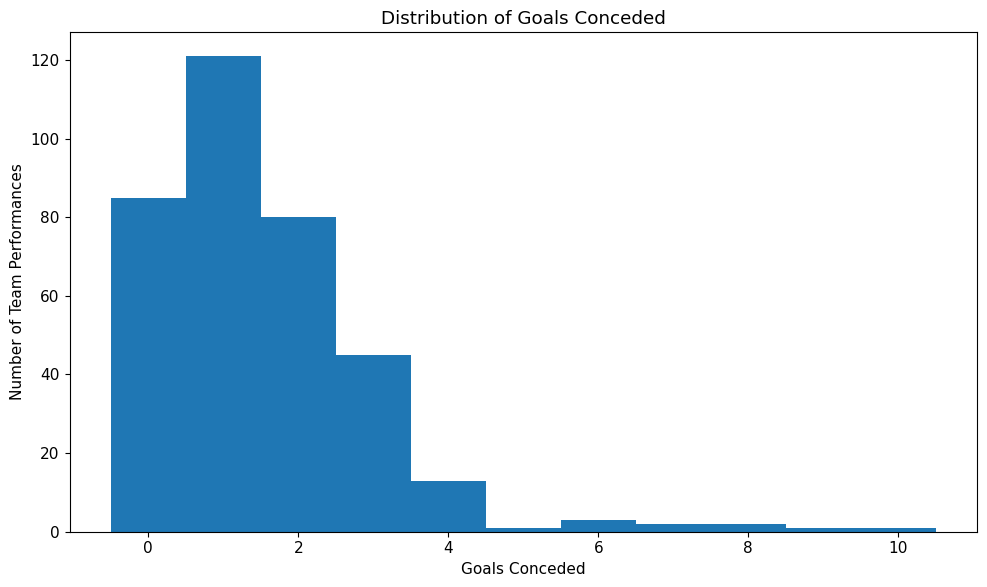

In [85]:
# Cell 119 - Goals Conceded Distribution

plt.figure(figsize=(10,6))

plt.hist(
    results["GA"],
    bins=range(0, results["GA"].max()+2),
    align="left"
)

plt.xlabel("Goals Conceded")
plt.ylabel("Number of Team Performances")
plt.title("Distribution of Goals Conceded")

plt.tight_layout()
plt.show()

In [86]:
# Cell 120 - Save Results Dataset

results.to_csv(
    "../data/processed/results_dataset.csv",
    index=False
)

print("Results dataset saved.")

Results dataset saved.


In [87]:
# Cell 121 - Project Summary

print("="*60)
print("KENYA HOCKEY UNION ANALYTICS")
print("="*60)

print(f"Matches scraped : {len(matches_df)}")
print(f"Events scraped  : {len(events_df)}")
print(f"Competitions    : {results['Competition'].nunique()}")
print(f"Teams           : {results['Team'].nunique()}")

print()
print("Matches per competition:")
print(matches_df["Competition"].value_counts())

print()

print("Processed datasets created:")
print("- matches.csv")
print("- events.csv")
print("- league_table.csv")
print("- team_summary.csv")
print("- player_goals.csv")
print("- card_summary.csv")
print("- team_goals.csv")
print("- minute_summary.csv")
print("- goals_per_game.csv")
print("- goals_conceded_per_game.csv")
print("- attack_defence_summary.csv")
print("- home_away_summary.csv")
print("- results_dataset.csv")


KENYA HOCKEY UNION ANALYTICS
Matches scraped : 177
Events scraped  : 209
Competitions    : 8
Teams           : 63

Matches per competition:
Competition
PLM       45
SLM       33
NLM-EZ    31
PLW       28
SLW       20
NLM-WZ    11
NLM-SZ     6
NLM-CZ     3
Name: count, dtype: int64

Processed datasets created:
- matches.csv
- events.csv
- league_table.csv
- team_summary.csv
- player_goals.csv
- card_summary.csv
- team_goals.csv
- minute_summary.csv
- goals_per_game.csv
- goals_conceded_per_game.csv
- attack_defence_summary.csv
- home_away_summary.csv
- results_dataset.csv


In [88]:
# cell 121A

matches_df.to_csv(
    "../data/processed/matches.csv",
    index=False
)

print("matches.csv saved.")

matches.csv saved.


In [89]:
# cell 121 B

events_df.to_csv(
    "../data/processed/events.csv",
    index=False
)

print("events.csv saved.")

events.csv saved.


In [90]:
# Save league_table as performance_metrics.csv
# (Required by 03_advanced_analytics.ipynb's loader — added so the
# pipeline is fully reproducible from a fresh clone, not dependent on
# leftover files from a previous run.)

league_table.to_csv(
    "../data/processed/performance_metrics.csv",
    index=False
)

print("performance_metrics.csv saved.")


performance_metrics.csv saved.
